## Enzo Marichal & Benoit Diene Projet Python

## Import window

In [4]:
%matplotlib inline

from datetime import datetime, date
from pathlib import Path
from io import BytesIO
from itertools import product
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, HRFlowable, PageBreak, CondPageBreak)
from reportlab.lib.enums import TA_CENTER, TA_LEFT
import yfinance as yf

NAMES = {"KC": "Café",  "CC": "Cacao", "CT": "Coton", "SB": "Sucre"}
COLORS = {"KC": "#36CC42","CC": "#21C8FF","CT": "#CE78F6","SB": "#E8A838"}

df_hist = pd.read_csv("continuous_series/ALL_continuous_OI_close.csv", index_col=0, parse_dates=True)
df_recent = pd.read_csv("continuous_series/ALL_continuous_OI_close_recent.csv", index_col=0, parse_dates=True)

## Graphiques individuels + base 100

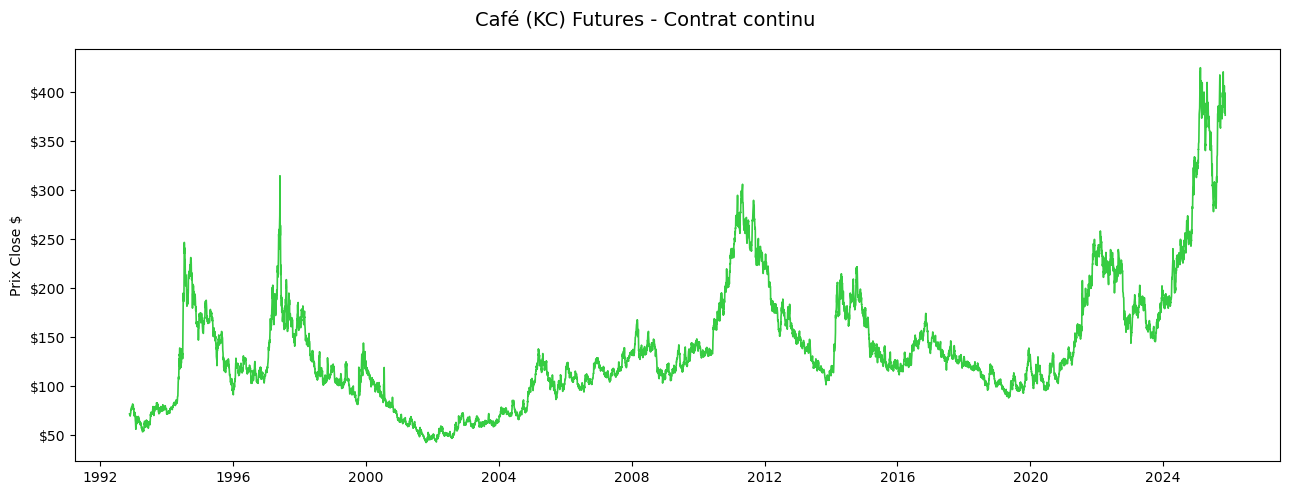

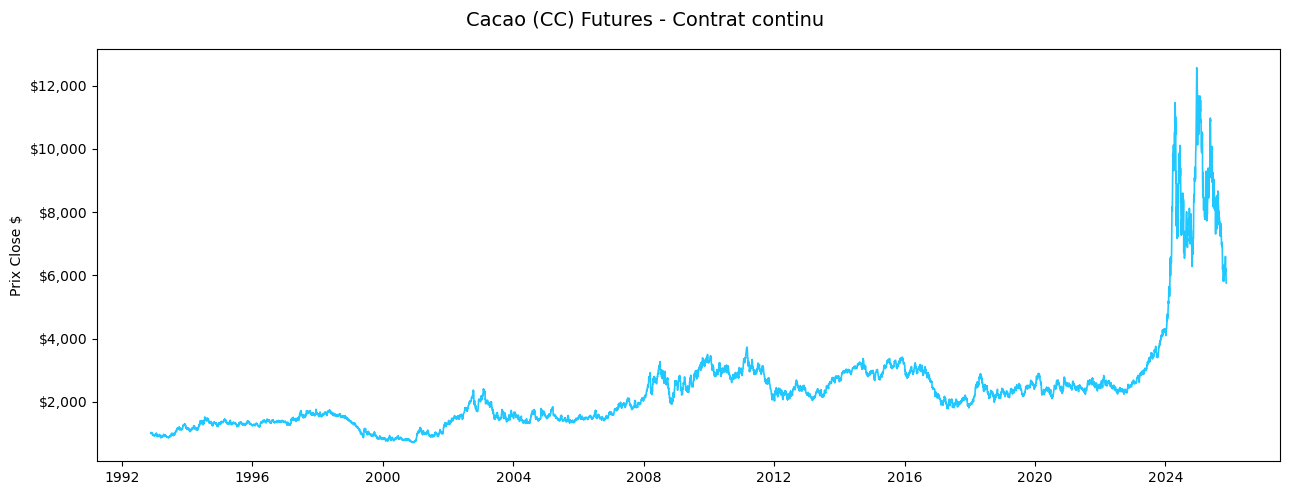

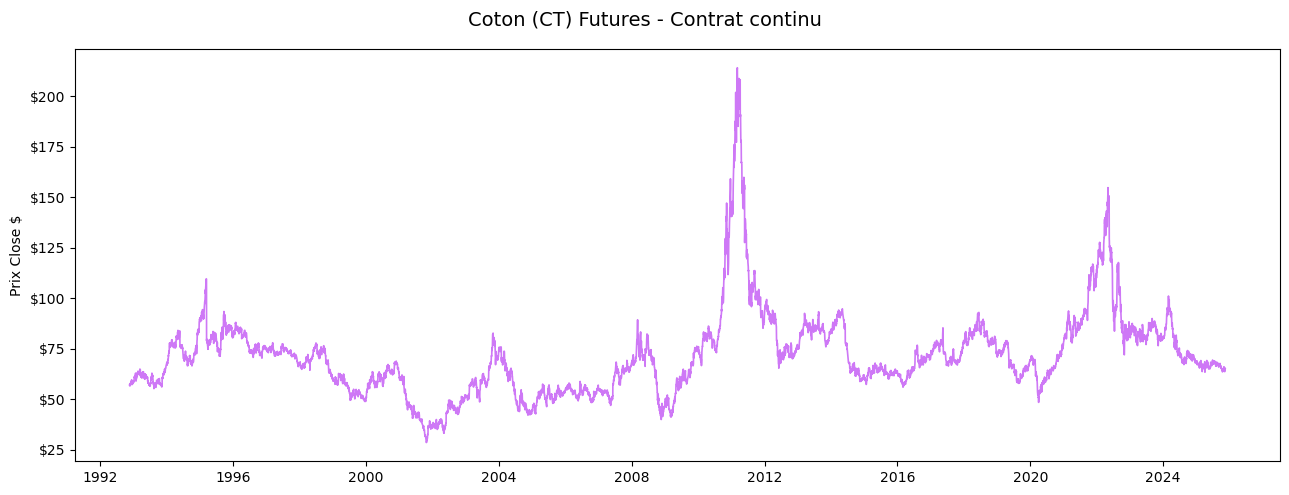

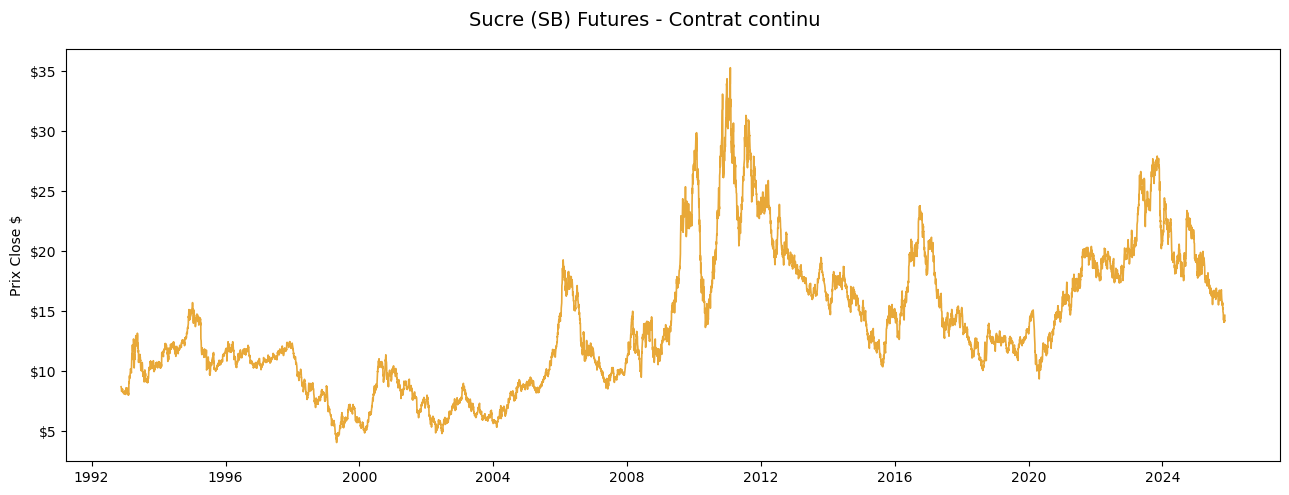

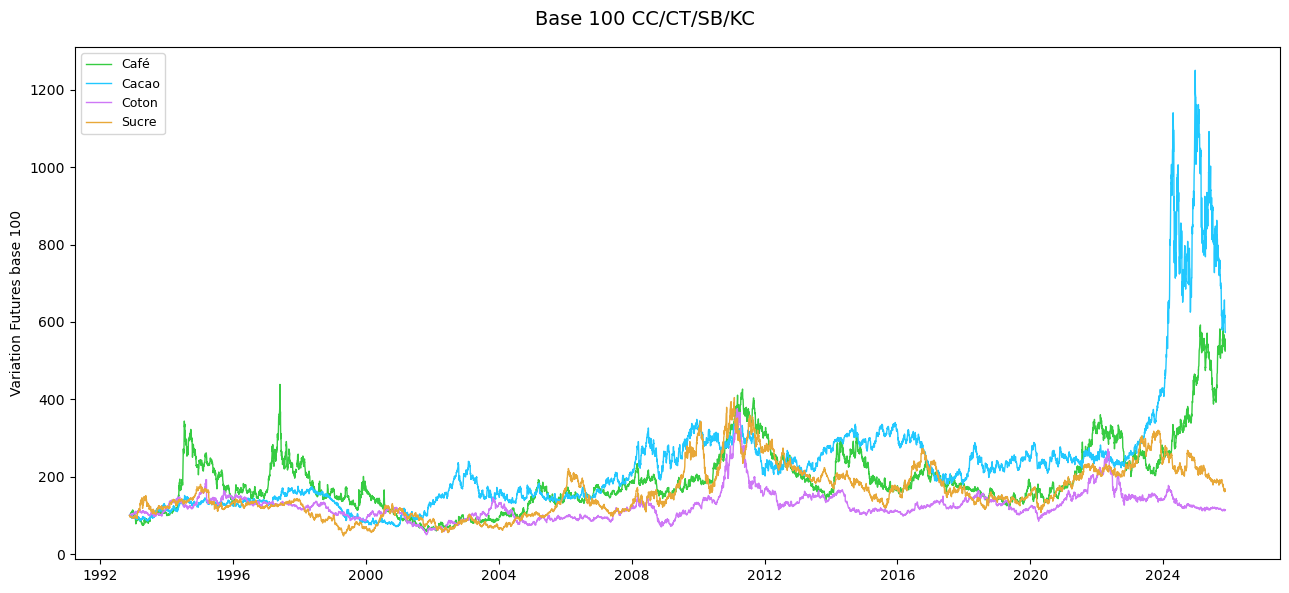

In [5]:
def get_dominant(filepath):
    df = pd.read_csv(filepath)
    df["date"] = pd.to_datetime(df["date"])
    df = df[df["measure"].isin(["close", "open_interest"])]
    df = df.sort_values(["date", "contract"]).groupby(["date", "contract", "measure"], as_index=False)["value"].last()

    wide = df.pivot(index=["date", "contract"], columns="measure", values="value").rename(columns={"close": "close", "open_interest": "oi"}).reset_index().dropna()

    idx = wide.groupby("date")["oi"].idxmax()
    dom = wide.loc[idx, ["date", "contract", "close", "oi"]].copy()
    dom = dom.sort_values("date").reset_index(drop=True)
    dom.columns = ["date", "dominant_contract", "dominant_close", "dominant_oi"]
    dom["rolled"] = dom["dominant_contract"].ne(dom["dominant_contract"].shift(1))
    dom["roll_id"] = dom["rolled"].cumsum()
    return dom

def plot_single(dom, name):
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.suptitle(f"{NAMES.get(name, name)} ({name}) Futures - Contrat continu", fontsize=14)

    ax.plot(dom["date"], dom["dominant_close"], lw=1.2, color=COLORS.get(name, "steelblue"))
    ax.set_ylabel("Prix Close $")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.show(block=True)
    plt.close()

def plot_base100(close_df):
    close_b = close_df.divide(close_df.apply(lambda s: s.dropna().iloc[0])) * 100

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.suptitle("Base 100 CC/CT/SB/KC", fontsize=14)

    for col in close_b.columns:
     ax.plot(close_b.index, close_b[col], label=NAMES.get(col, col),lw=1.0, color=COLORS.get(col))
    ax.set_ylabel("Variation Futures base 100")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show(block=True)
    plt.close()

if __name__ == "__main__":
    files = ["KC.csv", "CC.csv", "CT.csv", "SB.csv"]
    out_dir = Path("continuous_series")
    out_dir.mkdir(exist_ok=True)

    close_list = []

    for f in files:
        name = Path(f).stem
        dom = get_dominant(f)
        dom.to_csv(out_dir / f"{name}_continuous_OI.csv", index=False)
        plot_single(dom, name)
        close_list.append(dom.set_index("date")["dominant_close"].rename(name))

    combined_close = pd.concat(close_list, axis=1).sort_index()
    combined_close.to_csv(out_dir / "ALL_continuous_OI_close.csv")

    plot_base100(combined_close)

## Analyse De Tendance KC / CC / CT / SB


Café (KC)
Période : 1992-11-17 to 2025-11-13
Prix Range : $42 / $425 (actuel $377)

 Tendance
Marché Bull/Bear : 52% / 48%
Durée moyenne : 180j

 Volatilité
Volatilité Annuelle : 34.9%
Average True Range Moyen : $2.38 (1.7% du prix)
Max Drawdown : -86.5%

 Autocorrélation des rendements
Lag 1j : -0.022 (neutre)
Lag 5j : -0.022 (neutre)
Lag 21j : -0.023 (neutre)

 Distribution
Skew : +0.53
Kurtosis : +7.23


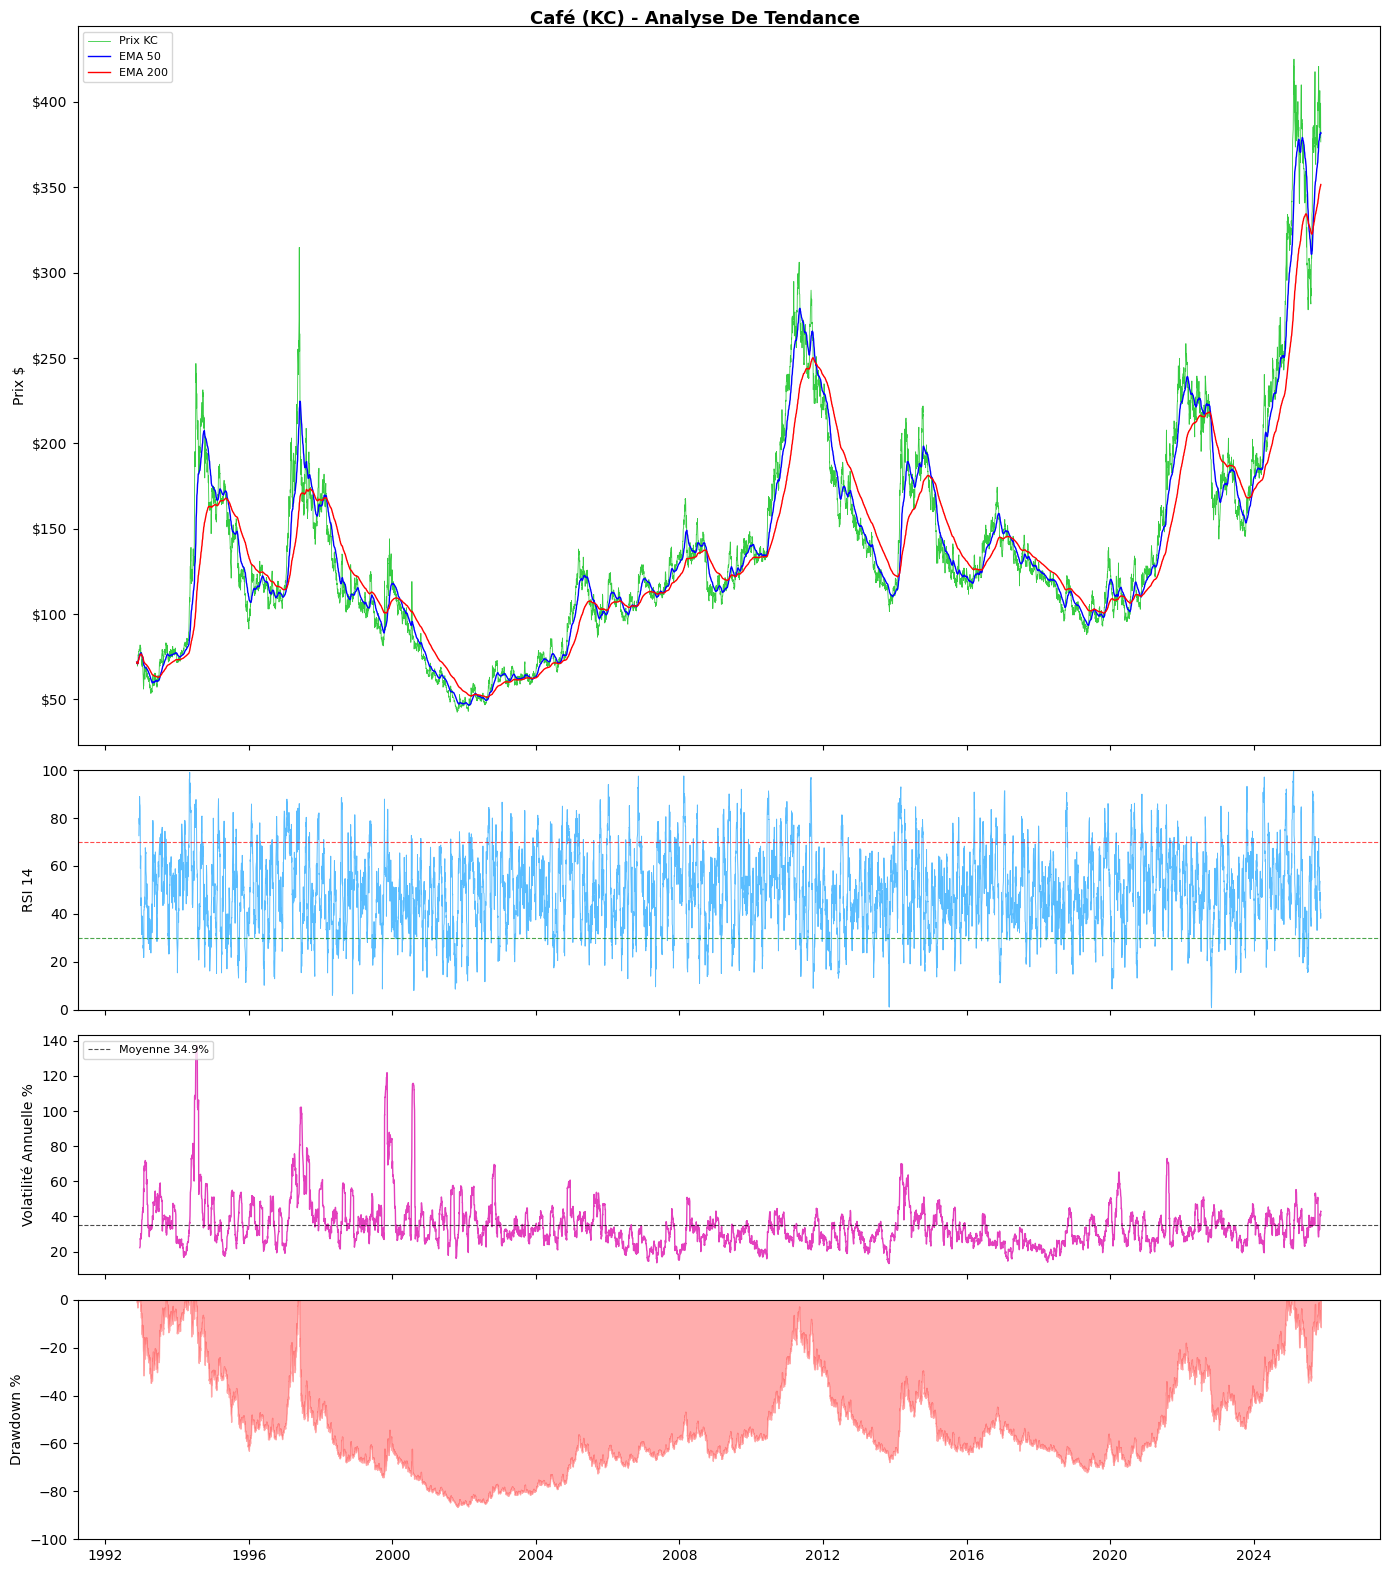

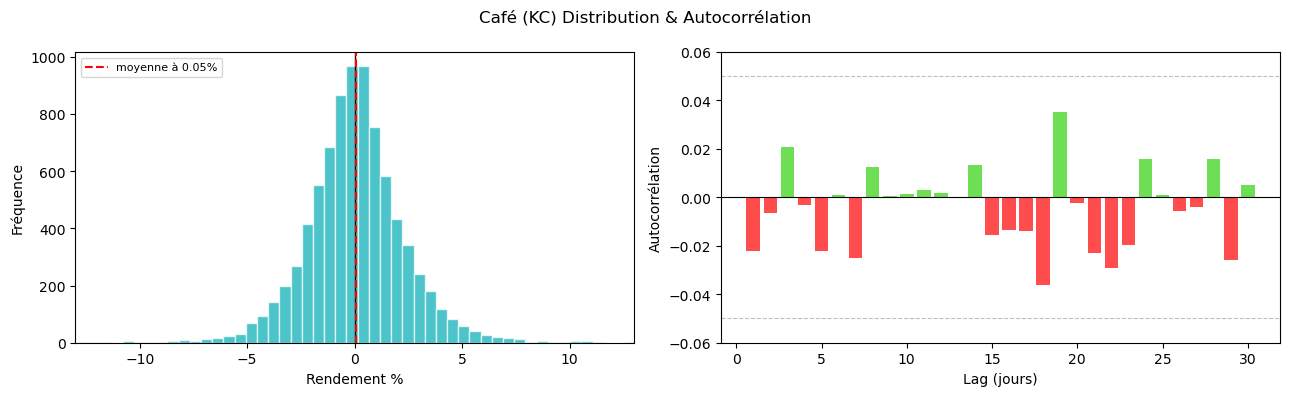


Cacao (CC)
Période : 1992-11-17 to 2025-11-13
Prix Range : $714 / $12565 (actuel $5757)

 Tendance
Marché Bull/Bear : 57% / 43%
Durée moyenne : 111j

 Volatilité
Volatilité Annuelle : 28.8%
Average True Range Moyen : $38.53 (1.4% du prix)
Max Drawdown : -59.5%

 Autocorrélation des rendements
Lag 1j : -0.016 (neutre)
Lag 5j : +0.034 (neutre)
Lag 21j : +0.001 (neutre)

 Distribution
Skew : -0.13
Kurtosis : +5.75


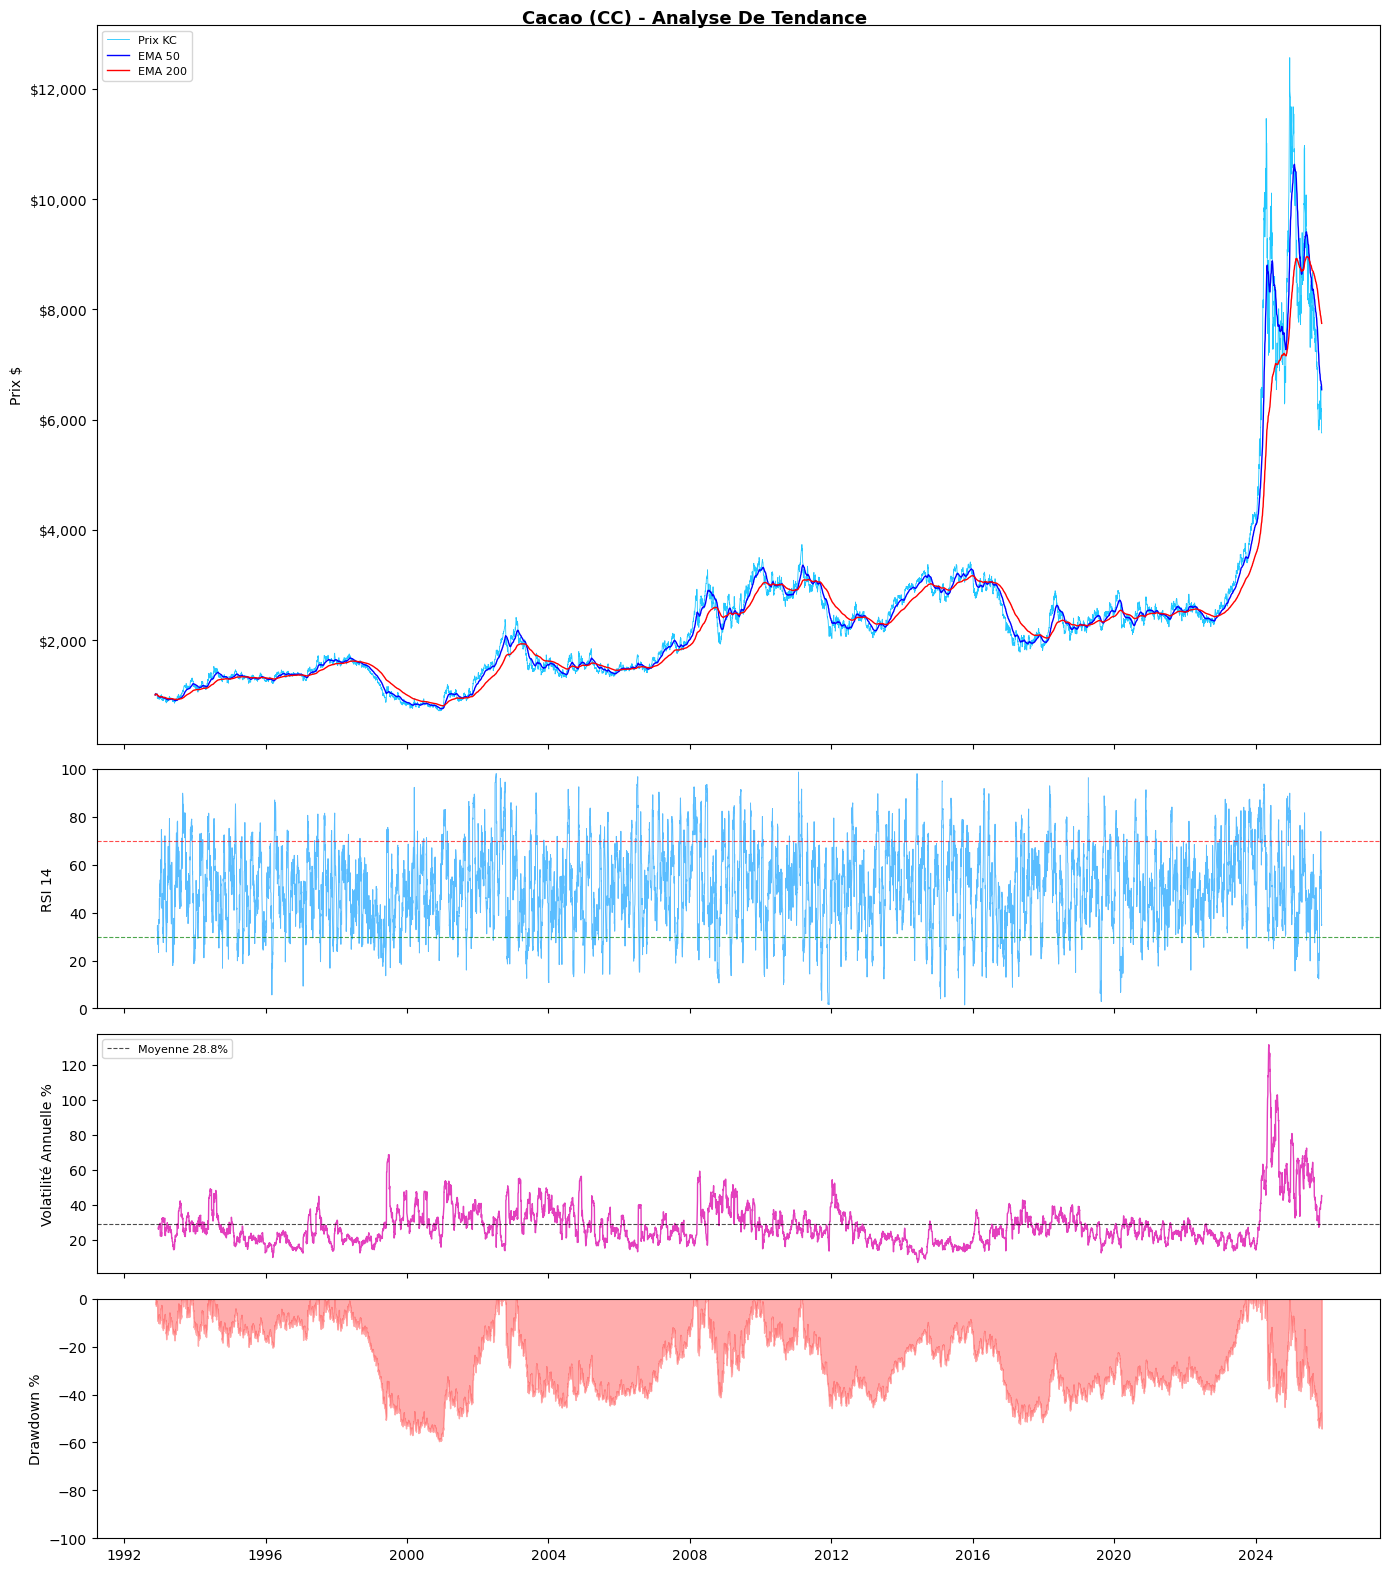

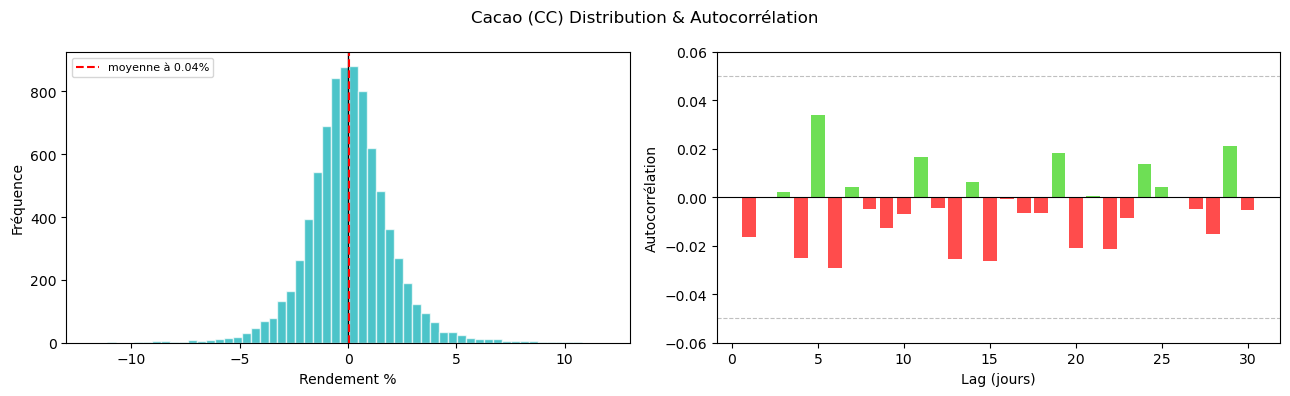


Coton (CT)
Période : 1992-11-17 to 2025-11-13
Prix Range : $29 / $214 (actuel $65)

 Tendance
Marché Bull/Bear : 48% / 52%
Durée moyenne : 185j

 Volatilité
Volatilité Annuelle : 25.0%
Average True Range Moyen : $0.87 (1.2% du prix)
Max Drawdown : -77.4%

 Autocorrélation des rendements
Lag 1j : +0.011 (neutre)
Lag 5j : -0.003 (neutre)
Lag 21j : +0.013 (neutre)

 Distribution
Skew : -0.26
Kurtosis : +14.64


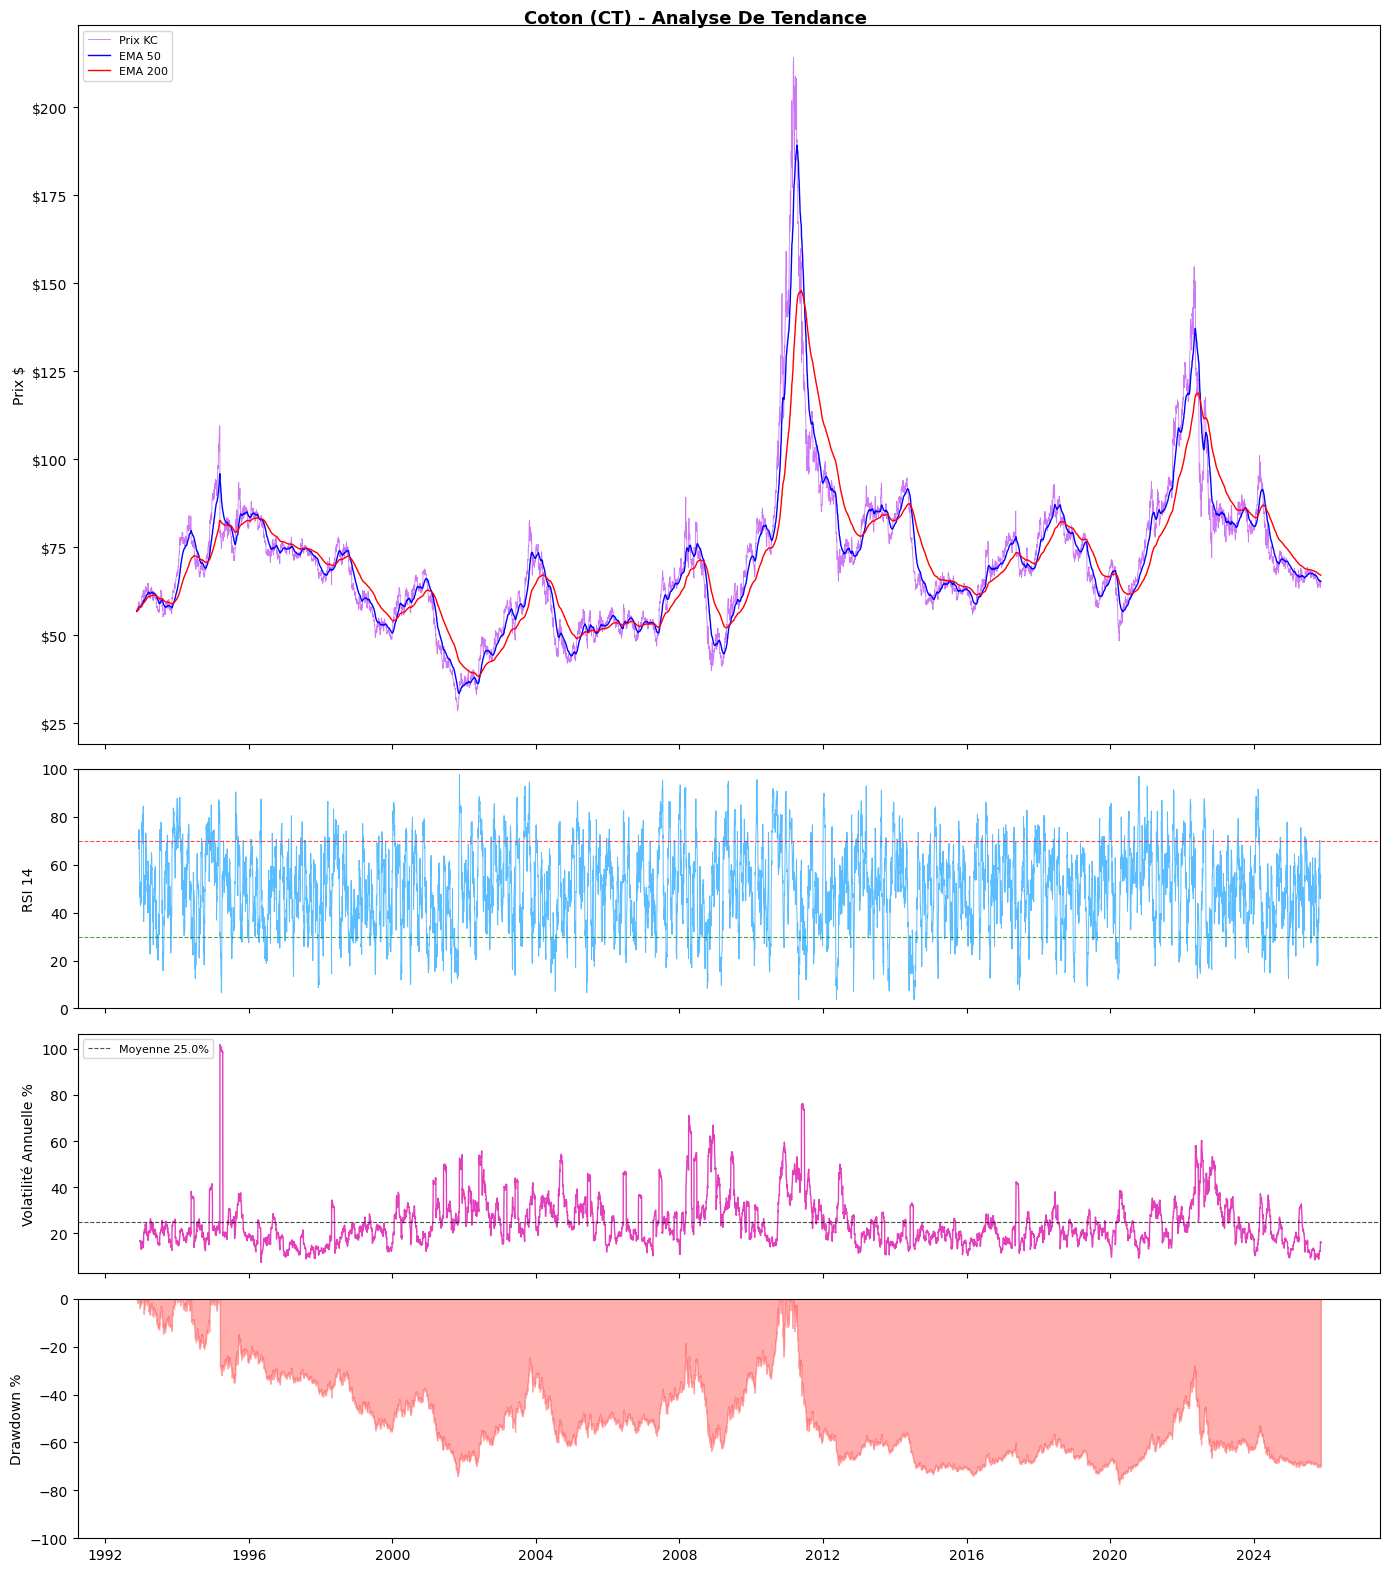

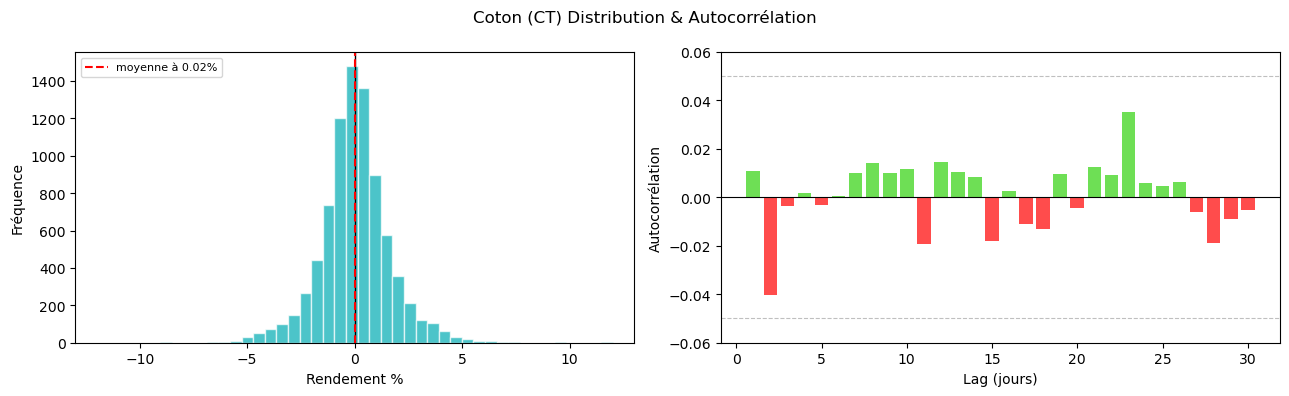


Sucre (SB)
Période : 1992-11-17 to 2025-11-13
Prix Range : $4 / $35 (actuel $15)

 Tendance
Marché Bull/Bear : 49% / 51%
Durée moyenne : 169j

 Volatilité
Volatilité Annuelle : 29.7%
Average True Range Moyen : $0.20 (1.4% du prix)
Max Drawdown : -74.1%

 Autocorrélation des rendements
Lag 1j : -0.014 (neutre)
Lag 5j : -0.008 (neutre)
Lag 21j : -0.020 (neutre)

 Distribution
Skew : +0.06
Kurtosis : +3.42


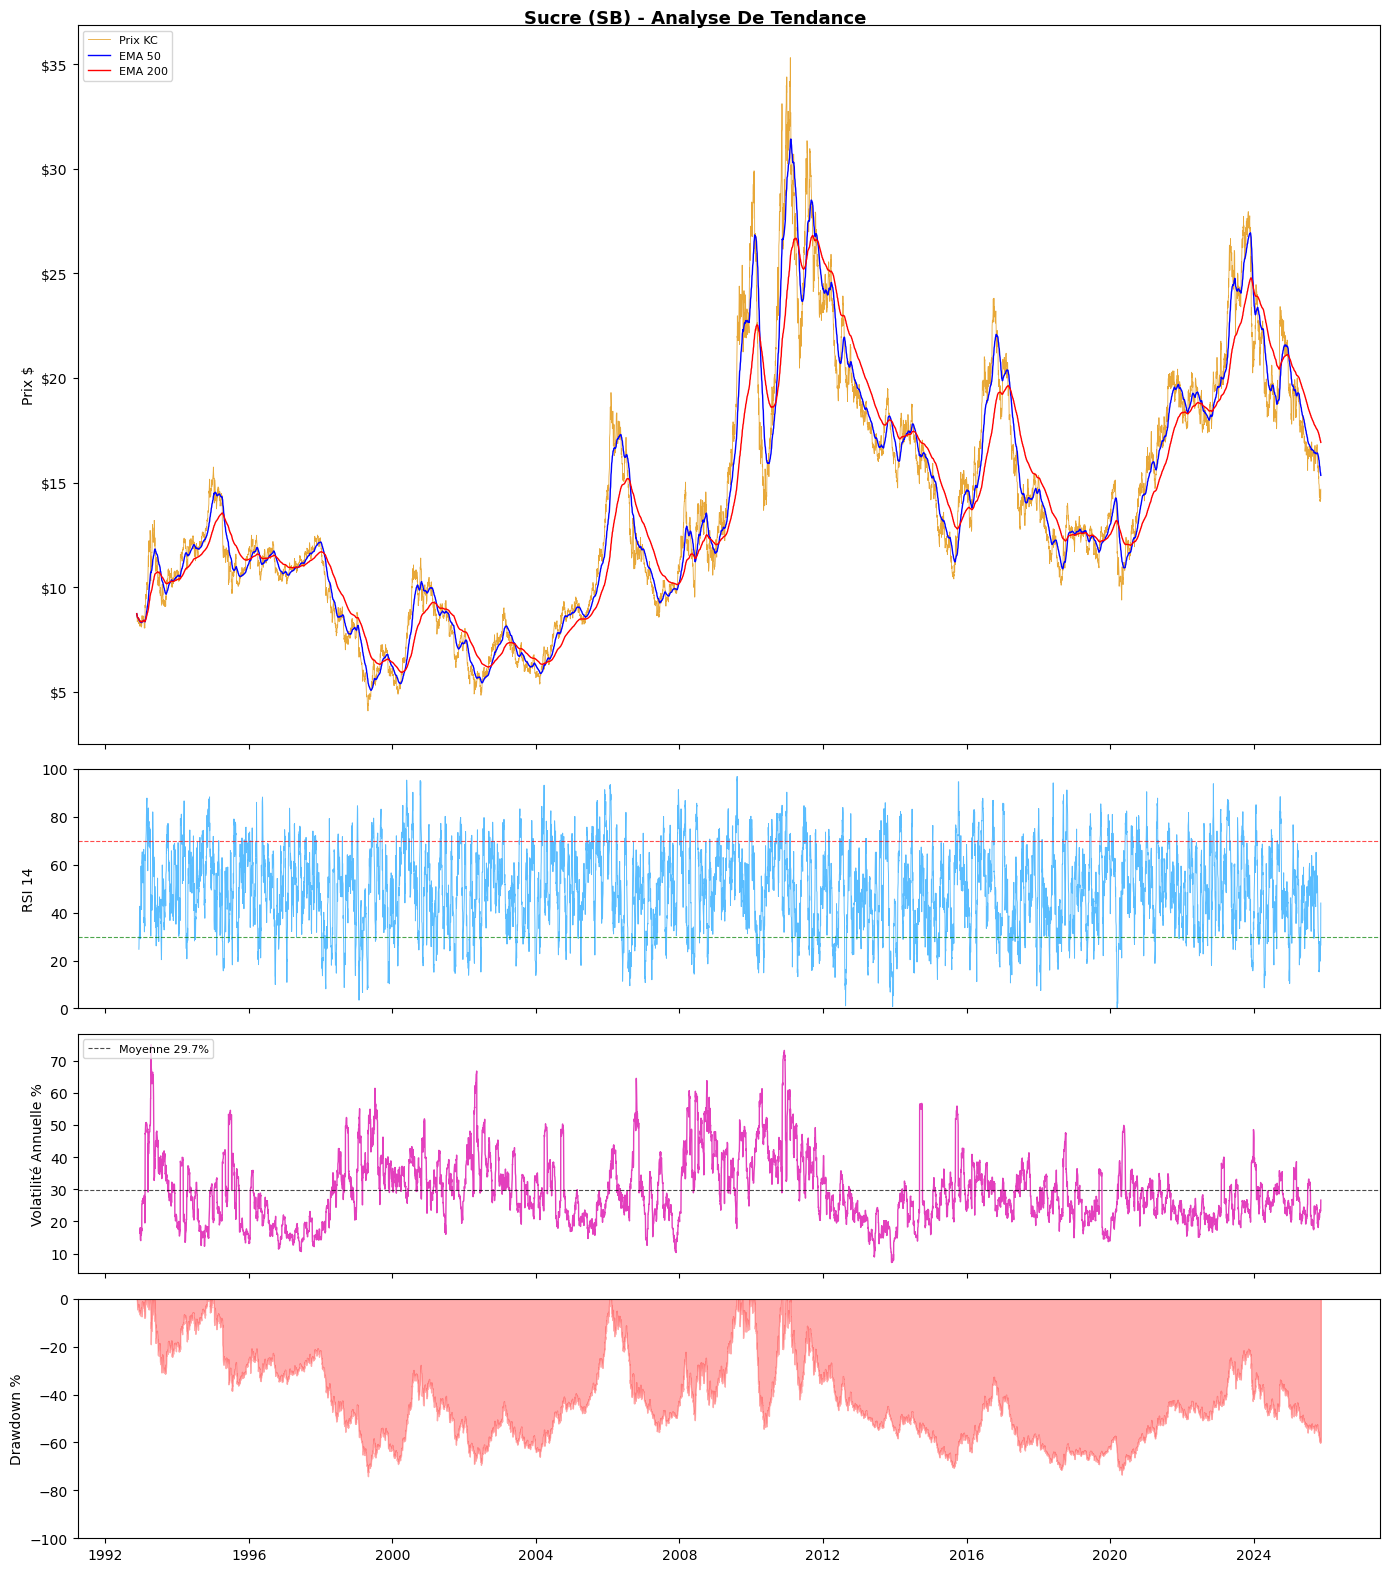

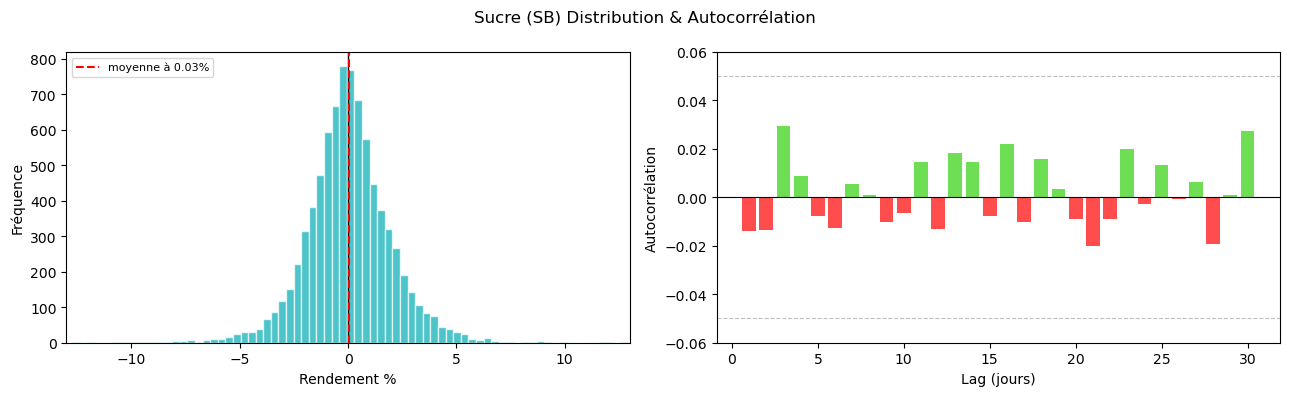

In [10]:
TICKERS = {"KC": "Café", "CC": "Cacao", "CT": "Coton", "SB": "Sucre"}

# Build df_all from your continuous series CSVs
df_all = pd.read_csv("continuous_series/ALL_continuous_OI_close.csv", index_col=0, parse_dates=True)

def analyze(prices, name):
    df = pd.DataFrame({"close": prices})
    df["returns"] = df["close"].pct_change()
    df["vol_21"] = df["returns"].rolling(21).std() * np.sqrt(252)
    df["atr_14"] = df["close"].diff().abs().rolling(14).mean()
    df["ema_50"] = df["close"].ewm(span=50).mean()
    df["ema_200"] = df["close"].ewm(span=200).mean()
    df["trend"] = np.where(df["ema_50"] > df["ema_200"], "bull", "bear")

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df["rsi"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    roll_max = df["close"].cummax()
    df["drawdown"] = (df["close"] - roll_max) / roll_max

    ac1 = df["returns"].autocorr(1)
    ac5 = df["returns"].autocorr(5)
    ac21 = df["returns"].autocorr(21)

    trend_runs = df["trend"].ne(df["trend"].shift(1)).cumsum()
    avg_trend = df.groupby(trend_runs).size().mean()

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Période : {prices.index.min().date()} to {prices.index.max().date()}")
    print(f"Prix Range : ${prices.min():.0f} / ${prices.max():.0f} (actuel ${prices.iloc[-1]:.0f})")
    print(f"\n Tendance")
    print(f"Marché Bull/Bear : {(df['trend']=='bull').mean()*100:.0f}% / {(df['trend']=='bear').mean()*100:.0f}%")
    print(f"Durée moyenne : {avg_trend:.0f}j")
    print(f"\n Volatilité")
    print(f"Volatilité Annuelle : {df['vol_21'].mean()*100:.1f}%")
    print(f"Average True Range Moyen : ${df['atr_14'].mean():.2f} ({(df['atr_14']/df['close']).mean()*100:.1f}% du prix)")
    print(f"Max Drawdown : {df['drawdown'].min()*100:.1f}%")
    print(f"\n Autocorrélation des rendements")

    def tag(v):
        if v < -0.05: return "mean-reversion"
        if v >  0.05: return "tendance"
        return "neutre"

    print(f"Lag 1j : {ac1:+.3f} ({tag(ac1)})")
    print(f"Lag 5j : {ac5:+.3f} ({tag(ac5)})")
    print(f"Lag 21j : {ac21:+.3f} ({tag(ac21)})")
    print(f"\n Distribution")
    print(f"Skew : {df['returns'].skew():+.2f}")
    print(f"Kurtosis : {df['returns'].kurt():+.2f}")

    return df

def plot_analysis(df, name, color):
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1, 1]})
    fig.suptitle(f"{name} - Analyse De Tendance", fontsize=13, fontweight="bold")

    ax1 = axes[0]
    ax1.plot(df.index, df["close"], lw=0.6, color=color, label="Prix KC")
    ax1.plot(df.index, df["ema_50"], lw=1.0, color="blue", label="EMA 50")
    ax1.plot(df.index, df["ema_200"], lw=1.0, color="red", label="EMA 200")
    ax1.set_ylabel("Prix $")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax1.legend(fontsize=8, loc="upper left")

    ax2 = axes[1]
    ax2.plot(df.index, df["rsi"], lw=0.7, color="#5ABDFF")
    ax2.axhline(70, lw=0.8, color="red", linestyle="--", alpha=0.7)
    ax2.axhline(30, lw=0.8, color="green", linestyle="--", alpha=0.7)
    ax2.set_ylabel("RSI 14")
    ax2.set_ylim(0, 100)

    ax3 = axes[2]
    ax3.plot(df.index, df["vol_21"]*100, lw=1, color="#E33FBD")
    ax3.axhline(df["vol_21"].mean()*100, lw=0.8, color="black", linestyle="--", alpha=0.7, label=f"Moyenne {df['vol_21'].mean()*100:.1f}%")
    ax3.set_ylabel("Volatilité Annuelle %")
    ax3.legend(fontsize=8, loc="upper left")

    ax4 = axes[3]
    ax4.fill_between(df.index, df["drawdown"]*100, 0, alpha=0.4, color="#FF3232")
    ax4.set_ylabel("Drawdown %")
    ax4.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
    ax4.set_ylim(-100, 0)

    plt.tight_layout()
    plt.show(block=True)
    plt.close()

    fig2, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4))
    fig2.suptitle(f"{name} Distribution & Autocorrélation", fontsize=12)

    r = df["returns"].dropna() * 100
    ax_a.hist(r, bins=80, color="#00ACB2", alpha=0.7, edgecolor="white", lw=0.3)
    ax_a.axvline(0, color="black", lw=1)
    ax_a.axvline(r.mean(), color="red", lw=1.5, linestyle="--", label=f"moyenne à {r.mean():.2f}%")
    ax_a.set_xlabel("Rendement %")
    ax_a.set_ylabel("Fréquence")
    ax_a.legend(fontsize=8, loc="upper left")
    ax_a.set_xlim(-13, 13)

    lags = range(1, 31)
    ac   = [df["returns"].autocorr(l) for l in lags]
    ax_b.bar(lags, ac, color=["#31D20D" if v > 0 else "#FF0000" for v in ac], alpha=0.7)
    ax_b.axhline(0, color="black", lw=0.8)
    ax_b.axhline(0.05, color="grey", lw=0.8, linestyle="--", alpha=0.5)
    ax_b.axhline(-0.05, color="grey", lw=0.8, linestyle="--", alpha=0.5)
    ax_b.set_xlabel("Lag (jours)")
    ax_b.set_ylabel("Autocorrélation")
    ax_b.set_ylim(-0.06, 0.06)

    plt.tight_layout()
    plt.show(block=True)
    plt.close()

for ticker, name in TICKERS.items():
    prices = df_all[ticker].dropna().sort_index()
    df = analyze(prices, f"{name} ({ticker})")
    plot_analysis(df, f"{name} ({ticker})", COLORS[ticker])

## Grid Search (optimal inputs) KC / CC / CT / SB - BB Strategy

In [ ]:
df_all = pd.read_csv("continuous_series/ALL_continuous_OI_close.csv", index_col=0, parse_dates=True)

GRID = {
    "bb_period": [15, 20, 30],
    "bb_std": [1.5, 2.0, 2.5],
    "atr_period": [10, 14, 20],
    "atr_expansion": [0.8, 1.0, 1.2],
    "sl_atr": [1.5, 2.0, 2.5],
    "chandelier_atr": [2.5, 3.0, 3.5],
    "tp_atr": [5.0, 6.0, 8.0],
    "contracts": [100],
}

def to_int(p):
    for k in ["bb_period", "atr_period", "contracts"]:
        if k in p:
            p[k] = int(p[k])
    return p

def indicators(prices, p):
    df = pd.DataFrame({"close": prices})

    df["bb_mid"] = df["close"].rolling(p["bb_period"]).mean()
    std = df["close"].rolling(p["bb_period"]).std()
    df["bb_upper"] = df["bb_mid"] + p["bb_std"] * std
    df["bb_lower"] = df["bb_mid"] - p["bb_std"] * std

    tr = pd.concat([(df["close"] - df["close"].shift(1)).abs(), df["close"].diff().abs()], axis=1).max(axis=1)
    df["atr"] = tr.rolling(p["atr_period"]).mean()
    df["atr_mean"] = df["atr"].rolling(50).mean()

    df["ch_long"] = df["close"].rolling(p["atr_period"]).max() - p["chandelier_atr"] * df["atr"]
    df["ch_short"] = df["close"].rolling(p["atr_period"]).min() + p["chandelier_atr"] * df["atr"]

    prev = df["close"].shift(1)
    df["bu"] = (df["close"] > df["bb_upper"]) & (prev <= df["bb_upper"].shift(1))
    df["bd"] = (df["close"] < df["bb_lower"]) & (prev >= df["bb_lower"].shift(1))

    return df.dropna()

def backtest(prices, p):
    p = to_int(p.copy())
    df = indicators(prices, p)
    qty = p["contracts"]

    pos = None
    trades = []
    cumul = 0.0
    last_sl = None

    for date, row in df.iterrows():
        price = row["close"]
        atr = row["atr"]

        if pos is not None:
            side = pos["side"]
            d = 1 if side == "long" else -1

            if side == "long":
                pos["trail"] = max(pos["trail"], row["ch_long"])
            else:
                pos["trail"] = min(pos["trail"], row["ch_short"])

            tp_hit = (side == "long" and price >= pos["tp"]) or (side == "short" and price <= pos["tp"])
            trail_hit = (side == "long" and price <= pos["trail"]) or (side == "short" and price >= pos["trail"])
            sl_hit = (side == "long" and price <= pos["sl"]) or (side == "short" and price >= pos["sl"])

            if tp_hit or trail_hit or sl_hit:
                if tp_hit:
                    ex = pos["tp"]
                elif trail_hit:
                    ex = pos["trail"]
                else:
                    ex = pos["sl"]
                pnl = d * (ex - pos["entry"]) * qty
                cumul += pnl
                trades.append(pnl)

                pos = None
                last_sl = date

        else:
            if last_sl is None or date > last_sl:
                exp = atr > p["atr_expansion"] * row["atr_mean"]

                if row["bu"] and exp:
                    pos = {"side": "long", "entry": price, "sl": price - p["sl_atr"] * atr, "tp": price + p["tp_atr"] * atr, "trail": row["ch_long"]}

                elif row["bd"] and exp:
                    pos = {"side": "short", "entry": price, "sl": price + p["sl_atr"] * atr, "tp": price - p["tp_atr"] * atr, "trail": row["ch_short"]}

    return {"trades": trades, "total": cumul}

def grid_search(prices, grid, top_n=10):
    keys = list(grid.keys())
    combos = list(product(*grid.values()))
    print(f"{len(combos)} combinaisons...")

    results = []
    for i, combo in enumerate(combos):
        p = to_int(dict(zip(keys, combo)))

        if p["sl_atr"] >= p["chandelier_atr"]: continue
        if p["chandelier_atr"] >= p["tp_atr"]: continue

        try:
            res = backtest(prices, p)
            tlist = res["trades"]
            if len(tlist) < 5: continue

            wins = [x for x in tlist if x > 0]
            losses = [x for x in tlist if x < 0]
            if not losses: continue

            results.append({**p,
                "total_pnl": round(res["total"], 0),
                "n_trades": len(tlist),
                "winrate": round(len(wins) / len(tlist), 3),
                "profit_factor": round(abs(sum(wins) / sum(losses)), 2),
            })
        except Exception:
            continue

        if (i + 1) % 200 == 0:
            print(f"{i+1}/{len(combos)}")

    df_res = pd.DataFrame(results)
    df_res["score"] = (
        df_res["total_pnl"].rank(pct=True) * 0.5 +
        df_res["profit_factor"].rank(pct=True) * 0.3 +
        df_res["winrate"].rank(pct=True) * 0.2
    )
    return df_res.sort_values("score", ascending=False).reset_index(drop=True).head(top_n)

TICKERS = {"KC": "Café", "CC": "Cacao", "CT": "Coton", "SB": "Sucre"}

for ticker, name in TICKERS.items():
    prices = df_all[ticker].dropna().sort_index()
    print(f"\n{name} ({ticker})") 
    top = grid_search(prices, GRID, top_n=10)
    print(top[["bb_period","bb_std","atr_period","atr_expansion", "sl_atr","chandelier_atr","tp_atr", "total_pnl","n_trades","winrate","profit_factor","score"]].to_string())


Café (KC)
2187 combinaisons...
200/2187
400/2187
600/2187
800/2187
1000/2187
1200/2187
1400/2187
1600/2187
1800/2187
2000/2187
   bb_period  bb_std  atr_period  atr_expansion  sl_atr  chandelier_atr  tp_atr  total_pnl  n_trades  winrate  profit_factor     score
0         30     1.5          10            1.0     2.0             2.5     8.0    49627.0       246    0.459           2.04  0.941795
1         30     1.5          10            1.0     1.5             2.5     8.0    49884.0       251    0.450           2.07  0.935237
2         30     1.5          10            0.8     2.0             2.5     8.0    66887.0       348    0.437           2.03  0.930581
3         30     1.5          10            0.8     2.5             3.0     8.0    59274.0       325    0.449           1.84  0.929192
4         15     1.5          20            0.8     2.0             2.5     8.0    70553.0       496    0.456           1.72  0.922197
5         30     1.5          14            1.0     2.0       

## Backtest with best parameters output + Visualisation KC / CC / CT / SB


Café Trading Strategy
Trades : 496
Winrate : 45.6%
PnL Total : $70,553
Meilleur : $4,549
Pire : $-1,532
Moyenne/trade : $142
LONG : n=270 $51,765 wr=46.3%
SHORT : n=226 $18,788 wr=44.7%


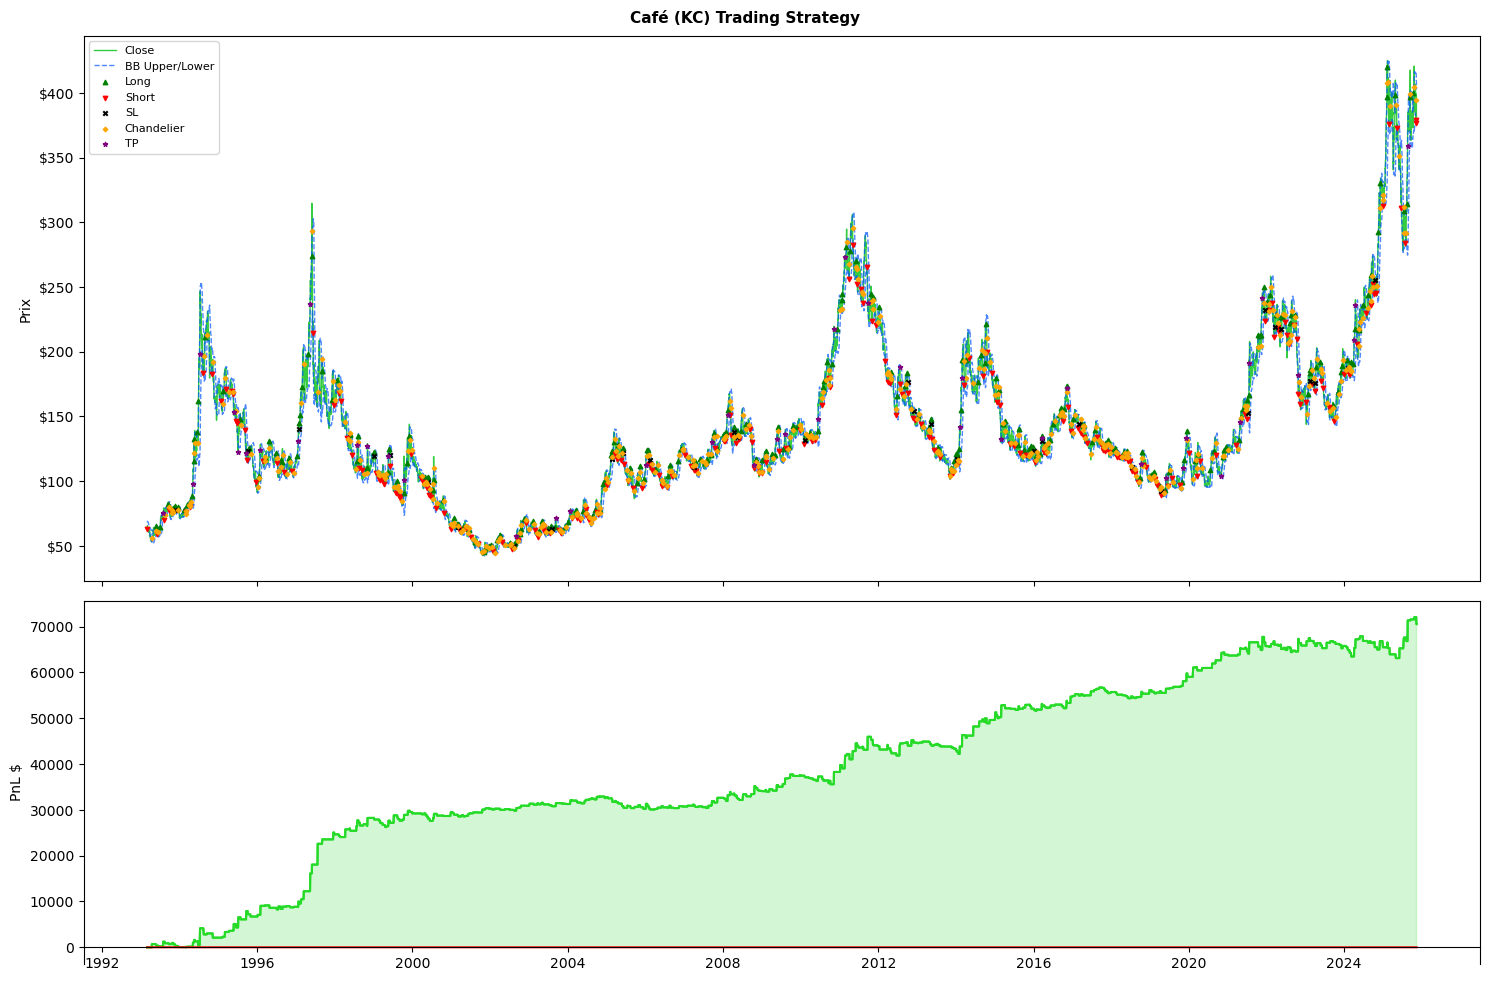


Cacao Trading Strategy
Trades : 84
Winrate : 47.6%
PnL Total : $665,493
Meilleur : $194,343
Pire : $-36,632
Moyenne/trade : $7,923
LONG : n=45 $450,654 wr=51.1%
SHORT : n=39 $214,839 wr=43.6%


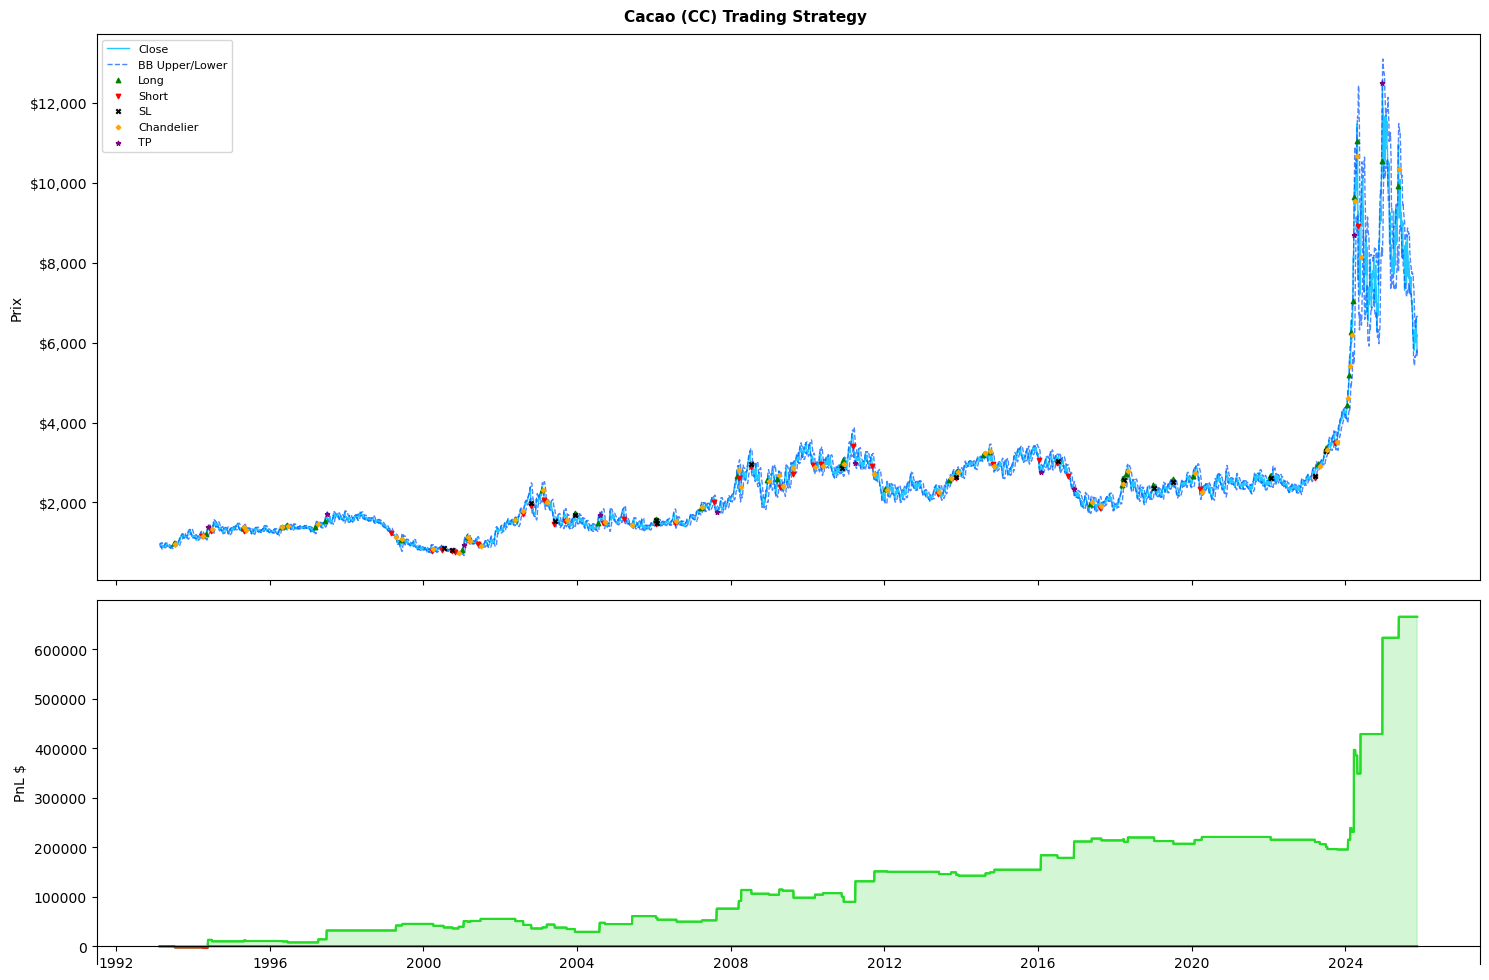


Coton Trading Strategy
Trades : 484
Winrate : 46.1%
PnL Total : $35,795
Meilleur : $4,070
Pire : $-1,112
Moyenne/trade : $74
LONG : n=267 $17,252 wr=44.2%
SHORT : n=217 $18,543 wr=48.4%


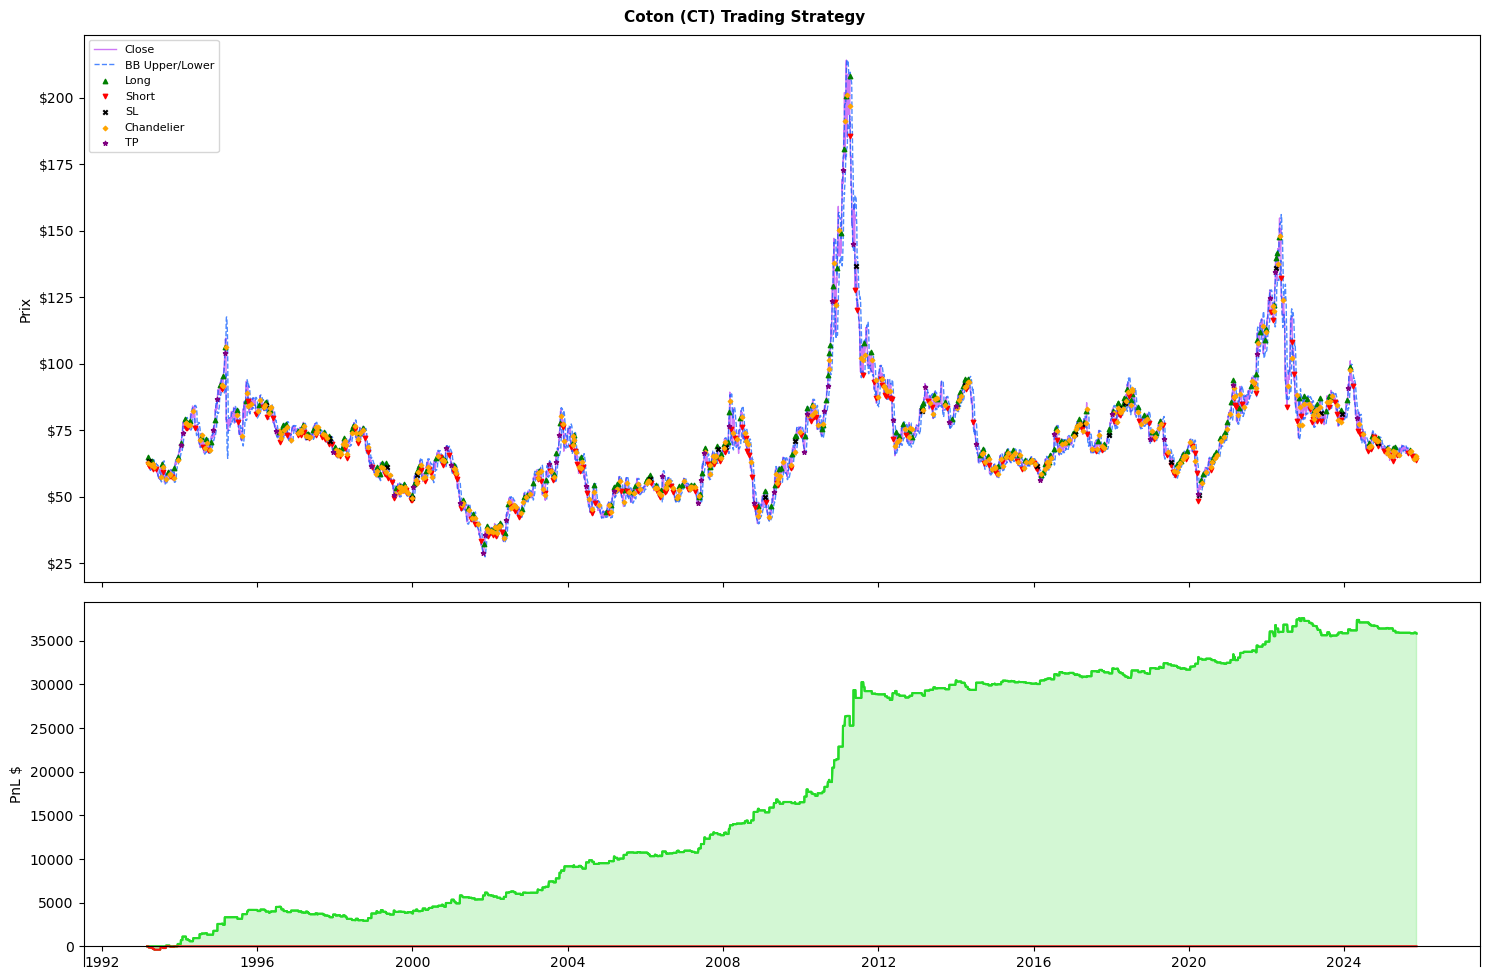


Sucre Trading Strategy
Trades : 302
Winrate : 46.4%
PnL Total : $5,557
Meilleur : $522
Pire : $-202
Moyenne/trade : $18
LONG : n=166 $3,053 wr=42.8%
SHORT : n=136 $2,504 wr=50.7%


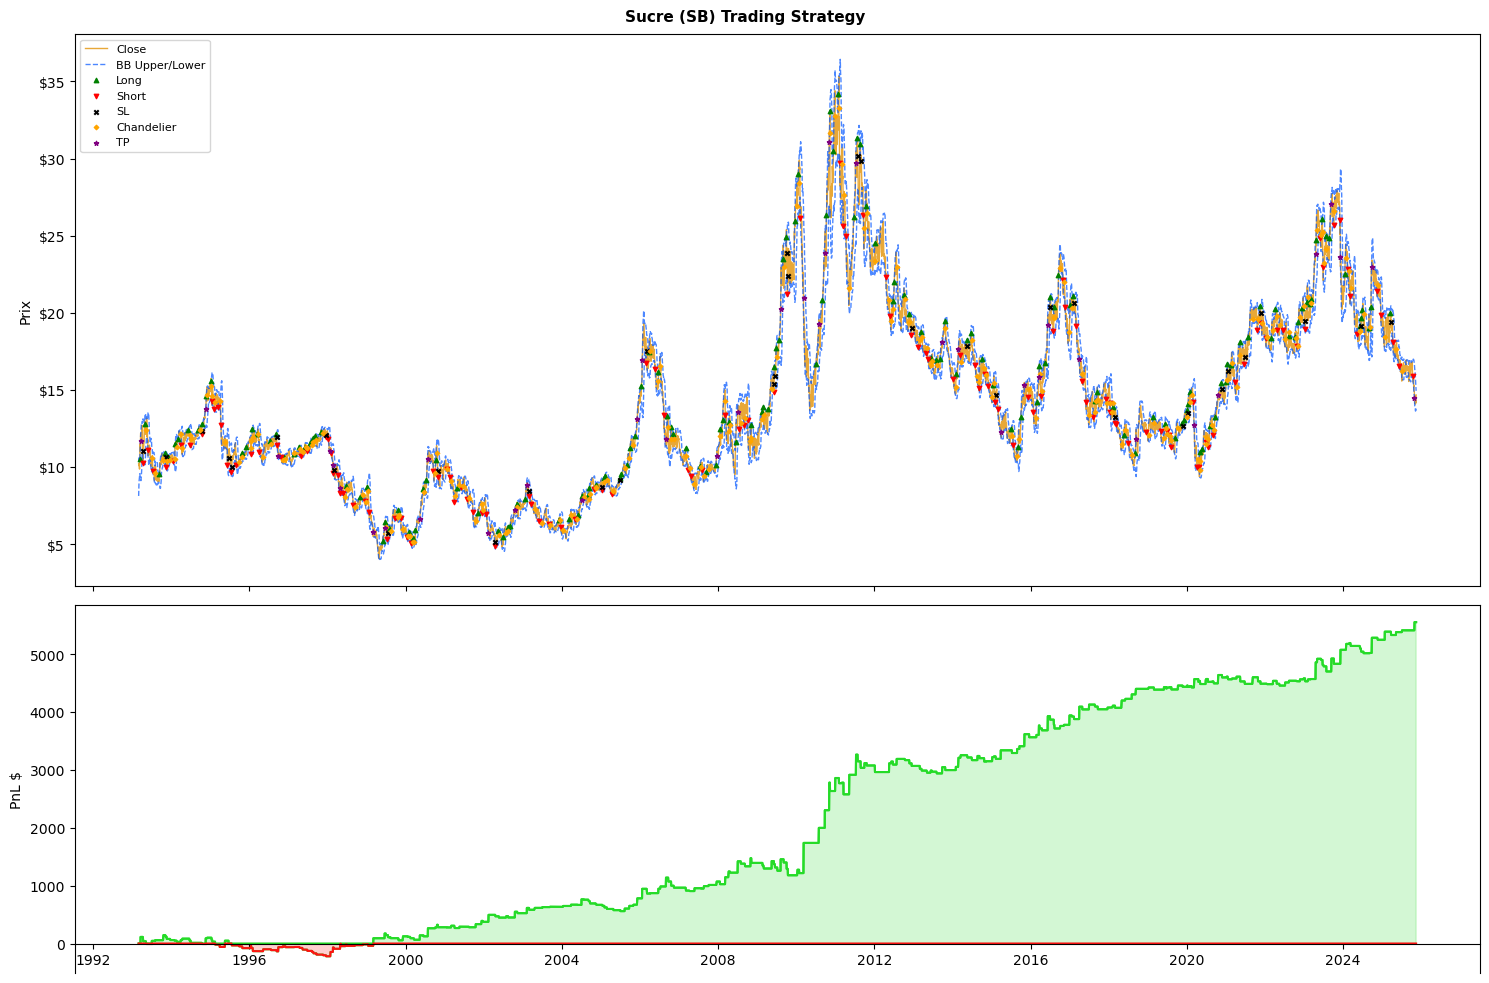


═════════════════════════════════════════════════════════
Ticker       Return $   Return %   Sharpe
─────────────────────────────────────────────────────
Café          +70,553     +70.6%     0.68
Cacao        +665,493    +665.5%     0.40
Coton         +35,795     +35.8%     0.75
Sucre          +5,557      +5.6%     0.62
─────────────────────────────────────────────────────
Total        +777,398    +777.4%     0.47
Ann. Return                  +23.7%
═════════════════════════════════════════════════════════


In [11]:
PARAMS = {
    "KC": {"contracts": 100, "bb_period": 15, "bb_std": 1.5, "atr_period": 20, "atr_expansion": 0.80, "sl_atr": 2.0, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "CC": {"contracts": 100, "bb_period": 15, "bb_std": 2.0, "atr_period": 14, "atr_expansion": 1.2, "sl_atr": 1.5, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "CT": {"contracts": 100, "bb_period": 15, "bb_std": 1.5, "atr_period": 20, "atr_expansion": 0.8, "sl_atr": 2.0, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "SB": {"contracts": 100, "bb_period": 15, "bb_std": 2.0, "atr_period": 20, "atr_expansion": 0.8, "sl_atr": 2.0, "chandelier_atr": 3.0, "tp_atr": 8.0},
}

NAMES = {"KC": "Café", "CC": "Cacao", "CT": "Coton", "SB": "Sucre"}

def indicators(prices, p):
    df = pd.DataFrame({"close": prices})

    df["bb_mid"] = df["close"].rolling(p["bb_period"]).mean()
    std = df["close"].rolling(p["bb_period"]).std()
    df["bb_upper"] = df["bb_mid"] + p["bb_std"] * std
    df["bb_lower"] = df["bb_mid"] - p["bb_std"] * std

    tr = pd.concat([(df["close"] - df["close"].shift(1)).abs(), df["close"].diff().abs()], axis=1).max(axis=1)
    df["atr"] = tr.rolling(p["atr_period"]).mean()
    df["atr_mean"] = df["atr"].rolling(50).mean()

    df["ch_long"] = df["close"].rolling(p["atr_period"]).max() - p["chandelier_atr"] * df["atr"]
    df["ch_short"] = df["close"].rolling(p["atr_period"]).min() + p["chandelier_atr"] * df["atr"]

    prev = df["close"].shift(1)
    df["bu"] = (df["close"] > df["bb_upper"]) & (prev <= df["bb_upper"].shift(1))
    df["bd"] = (df["close"] < df["bb_lower"]) & (prev >= df["bb_lower"].shift(1))

    return df.dropna()

def backtest(prices, p):
    df = indicators(prices, p)
    qty = p["contracts"]

    pos = None
    trades = []
    curve = []
    cumul = 0.0
    last_sl = None

    for date, row in df.iterrows():
        price = row["close"]
        atr = row["atr"]

        if pos is not None:
            side = pos["side"]
            d = 1 if side == "long" else -1

            if side == "long":
                pos["trail"] = max(pos["trail"], row["ch_long"])
            else:
                pos["trail"] = min(pos["trail"], row["ch_short"])

            tp_hit = (side == "long" and price >= pos["tp"]) or (side == "short" and price <= pos["tp"])
            trail_hit = (side == "long" and price <= pos["trail"]) or (side == "short" and price >= pos["trail"])
            sl_hit = (side == "long" and price <= pos["sl"]) or (side == "short" and price >= pos["sl"])

            if tp_hit or trail_hit or sl_hit:
                if tp_hit:
                    ex, tag = pos["tp"], f"TP ${pos['tp']:.0f}"
                elif trail_hit:
                    ex, tag = pos["trail"], "CHANDELIER"
                else:
                    ex, tag = pos["sl"], "STOP LOSS"

                pnl = d * (ex - pos["entry"]) * qty
                cumul += pnl
                trades.append({"date": date, "side": side, "action": tag, "price": ex, "qty": qty, "pnl": pnl, "cumul_pnl": cumul})
                pos = None
                last_sl = date
                curve.append({"date": date, "cumul_pnl": cumul})
                continue

        else:
            if last_sl is None or date > last_sl:
                exp = atr > p["atr_expansion"] * row["atr_mean"]

                if row["bu"] and exp:
                    pos = {"side": "long", "entry": price, "sl": price - p["sl_atr"] * atr, "tp": price + p["tp_atr"] * atr, "trail": row["ch_long"]}
                    trades.append({"date": date, "side": "long", "action": "ENTREE LONG", "price": price, "qty": qty, "pnl": 0, "cumul_pnl": cumul})

                elif row["bd"] and exp:
                    pos = {"side": "short", "entry": price, "sl": price + p["sl_atr"] * atr, "tp": price - p["tp_atr"] * atr, "trail": row["ch_short"]}
                    trades.append({"date": date, "side": "short", "action": "ENTREE SHORT", "price": price, "qty": qty, "pnl": 0, "cumul_pnl": cumul})

        curve.append({"date": date, "cumul_pnl": cumul})

    return {
        "df":     df,
        "trades": pd.DataFrame(trades),
        "curve":  pd.DataFrame(curve).set_index("date"),
        "total":  cumul,
    }

def summary(trades, name):
    closed = trades[trades["pnl"] != 0]
    wins = closed[closed["pnl"] > 0]
    losses = closed[closed["pnl"] < 0]

    print(f"\n{name} Trading Strategy")
    print(f"Trades : {len(closed)}")
    print(f"Winrate : {100*len(wins)/len(closed):.1f}%")
    print(f"PnL Total : ${closed['pnl'].sum():,.0f}")
    print(f"Meilleur : ${closed['pnl'].max():,.0f}")
    print(f"Pire : ${closed['pnl'].min():,.0f}")
    print(f"Moyenne/trade : ${closed['pnl'].mean():,.0f}")

    for side in ["long", "short"]:
        sub = closed[closed["side"] == side]
        if not sub.empty:
            wr = 100 * len(sub[sub["pnl"] > 0]) / len(sub)
            print(f"{side.upper()} : n={len(sub)} ${sub['pnl'].sum():,.0f} wr={wr:.1f}%")

def plot_results(res, ticker, name):
    df = res["df"]
    tr = res["trades"]
    curve = res["curve"]

    el = tr[tr["action"] == "ENTREE LONG"]
    es = tr[tr["action"] == "ENTREE SHORT"]
    sl = tr[tr["action"] == "STOP LOSS"]
    ch = tr[tr["action"] == "CHANDELIER"]
    tp = tr[tr["action"].str.startswith("TP")]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
    fig.suptitle(f"{name} ({ticker}) Trading Strategy", fontsize=11, fontweight="bold")

    ax1.plot(df.index, df["close"], lw=1, color=COLORS[ticker], label="Close")
    ax1.plot(df.index, df["bb_upper"], lw=1, color="#0055FF", linestyle="--", label="BB Upper/Lower", alpha=0.7)
    ax1.plot(df.index, df["bb_lower"], lw=1, color="#0055FF", linestyle="--", alpha=0.7)

    for data, marker, color, label, sz in [
        (el, "^", "green", "Long", 10),
        (es, "v", "red", "Short", 10),
        (sl, "x", "black", "SL", 10),
        (ch, "D", "orange", "Chandelier", 5),
        (tp, "*", "purple", "TP", 10),
    ]:
        if not data.empty:
            ax1.scatter(data["date"], data["price"], marker=marker, color=color, s=sz, zorder=5, label=label)

    ax1.set_ylabel("Prix")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax1.legend(loc="upper left", fontsize=8)

    ax2.plot(curve.index, curve["cumul_pnl"], lw=1.5, color="#25DB28")
    ax2.plot(curve.index, curve["cumul_pnl"].clip(lower=0), lw=1.5, color="#25DB28")
    ax2.plot(curve.index, curve["cumul_pnl"].clip(upper=0), lw=1.5, color="#FF1212")
    ax2.spines["bottom"].set_position(("data", 0))
    ax2.fill_between(curve.index, curve["cumul_pnl"], 0, where=curve["cumul_pnl"] >= 0, alpha=0.2, color="#25DB28")
    ax2.fill_between(curve.index, curve["cumul_pnl"], 0, where=curve["cumul_pnl"] < 0, alpha=0.2, color="#FF1212")
    ax2.set_ylabel("PnL $")

    plt.tight_layout()
    plt.show(block=True)
    plt.close()

def global_summary(results):
    initial = 100_000
    print(f"\n{'═'*57}")
    print(f"{'Ticker':<8} {'Return $':>12} {'Return %':>10} {'Sharpe':>8}")
    print(f"{'─'*53}")
    total_pnl = 0
    all_daily = None
    for ticker, (res, name) in results.items():
        closed = res["trades"][res["trades"]["pnl"] != 0]
        pnl = closed["pnl"].sum()
        ret_pct = pnl / initial * 100
        daily = res["curve"]["cumul_pnl"].diff().fillna(0)
        sharpe = (daily.mean() / daily.std() * np.sqrt(252)) if daily.std() > 0 else 0
        total_pnl += pnl
        all_daily = daily if all_daily is None else all_daily.add(daily, fill_value=0)
        print(f"{name:<8} {pnl:>+12,.0f} {ret_pct:>+9.1f}% {sharpe:>8.2f}")

    sharpe_total = (all_daily.mean() / all_daily.std() * np.sqrt(252)) if all_daily.std() > 0 else 0
    ann_ret = (total_pnl / initial * 100) / (len(all_daily) / 252)

    print(f"{'─'*53}")
    print(f"{'Total':<8} {total_pnl:>+12,.0f} {total_pnl/initial*100:>+9.1f}% {sharpe_total:>8.2f}")
    print(f"{'Ann. Return':<8} {'':>12} {ann_ret:>+9.1f}%")
    print(f"{'═'*57}")
    
results = {}
for ticker, name in NAMES.items():
    prices = df_all[ticker].dropna().sort_index()
    res = backtest(prices, PARAMS[ticker])
    summary(res["trades"], name)
    plot_results(res, ticker, name)
    results[ticker] = (res, name)

global_summary(results)

## Récolter les données nouvelles sur les contrats pour tester la stratégie LIVE

In [12]:
TICKERS = {"KC": "KC=F","CC": "CC=F","CT": "CT=F","SB": "SB=F",}

START = "2025-11-13"
END = "2026-03-14"

print(f"Téléchargement du {START} au {END}...")

close_list = []
for name, yf_ticker in TICKERS.items():
    print(f"{name} ({yf_ticker})...")
    data = yf.download(yf_ticker, start=START, end=END, auto_adjust=True, progress=False)
    if data.empty:
        print(f" Aucune donnée pour {yf_ticker}")
        continue
    serie = data["Close"].squeeze().rename(name)
    serie = serie.dropna().sort_index()
    print(f" {len(serie)} jours récupérés | dernier prix : {serie.iloc[-1]:.4f}")
    close_list.append(serie)

combined = pd.concat(close_list, axis=1).sort_index()
combined.index.name = "date"

out = "continuous_series/ALL_continuous_OI_close_recent.csv"
combined.to_csv(out)
print(f"\nFichier sauvegardé : {out}")
print(combined.tail())

Téléchargement du 2025-11-13 au 2026-03-14...
KC (KC=F)...
 82 jours récupérés | dernier prix : 285.1500
CC (CC=F)...
 81 jours récupérés | dernier prix : 3223.0000
CT (CT=F)...
 82 jours récupérés | dernier prix : 65.8200
SB (SB=F)...
 82 jours récupérés | dernier prix : 14.4100

Fichier sauvegardé : continuous_series/ALL_continuous_OI_close_recent.csv
                    KC      CC         CT     SB
date                                            
2026-03-09  301.750000  3197.0  63.590000  14.59
2026-03-10  300.549988  3356.0  65.300003  14.38
2026-03-11  292.000000  3337.0  65.169998  14.25
2026-03-12  296.500000  3223.0  65.139999  14.38
2026-03-13  285.149994     NaN  65.820000  14.41


### Test Strategy Live (Hors Echantillon with best parameters) From 2025-11-13 to Today (previous entered date in the above code)


Café (2025-11-13 à Aujourd'hui) Trading Strategy
Trades : 3
Winrate : 33.3%
PnL Total : $908
Meilleur : $4,960
Pire : $-2,223
Moyenne/trade : $303
LONG : n=1 $-1,829 wr=0.0%
SHORT : n=2 $2,737 wr=50.0%


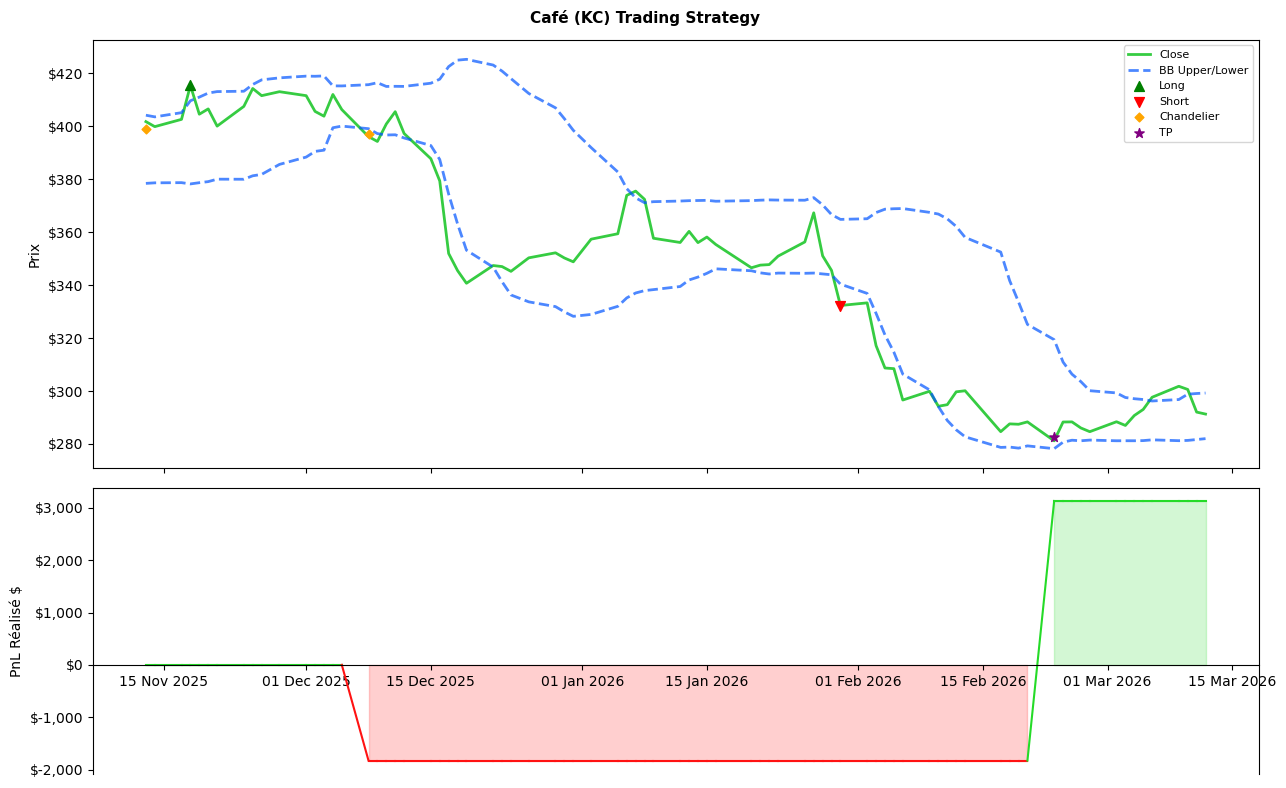


Cacao (2025-11-13 à Aujourd'hui) Trading Strategy
Trades : 2
Winrate : 100.0%
PnL Total : $146,182
Meilleur : $122,800
Pire : $23,382
Moyenne/trade : $73,091
SHORT : n=2 $146,182 wr=100.0%


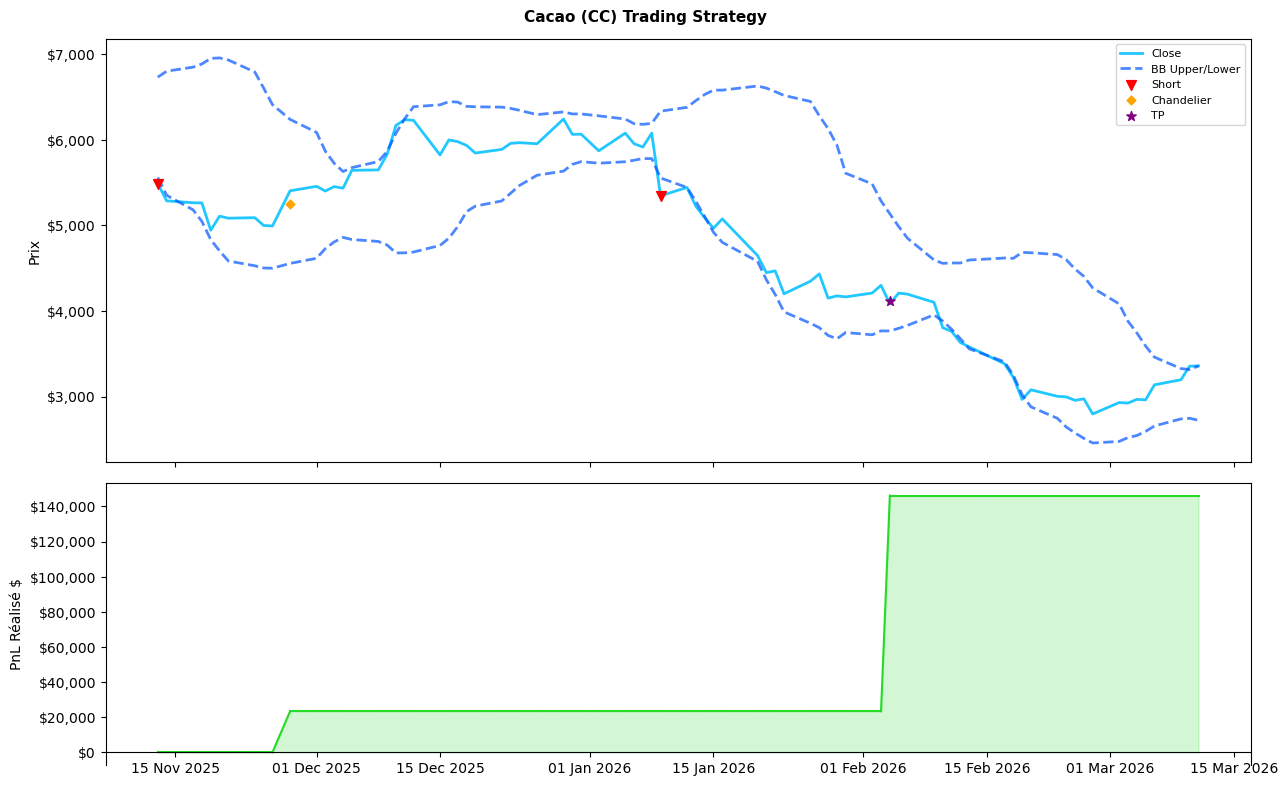


Coton (2025-11-13 à Aujourd'hui) Trading Strategy
Trades : 4
Winrate : 100.0%
PnL Total : $208
Meilleur : $132
Pire : $17
Moyenne/trade : $52
LONG : n=2 $60 wr=100.0%
SHORT : n=2 $148 wr=100.0%


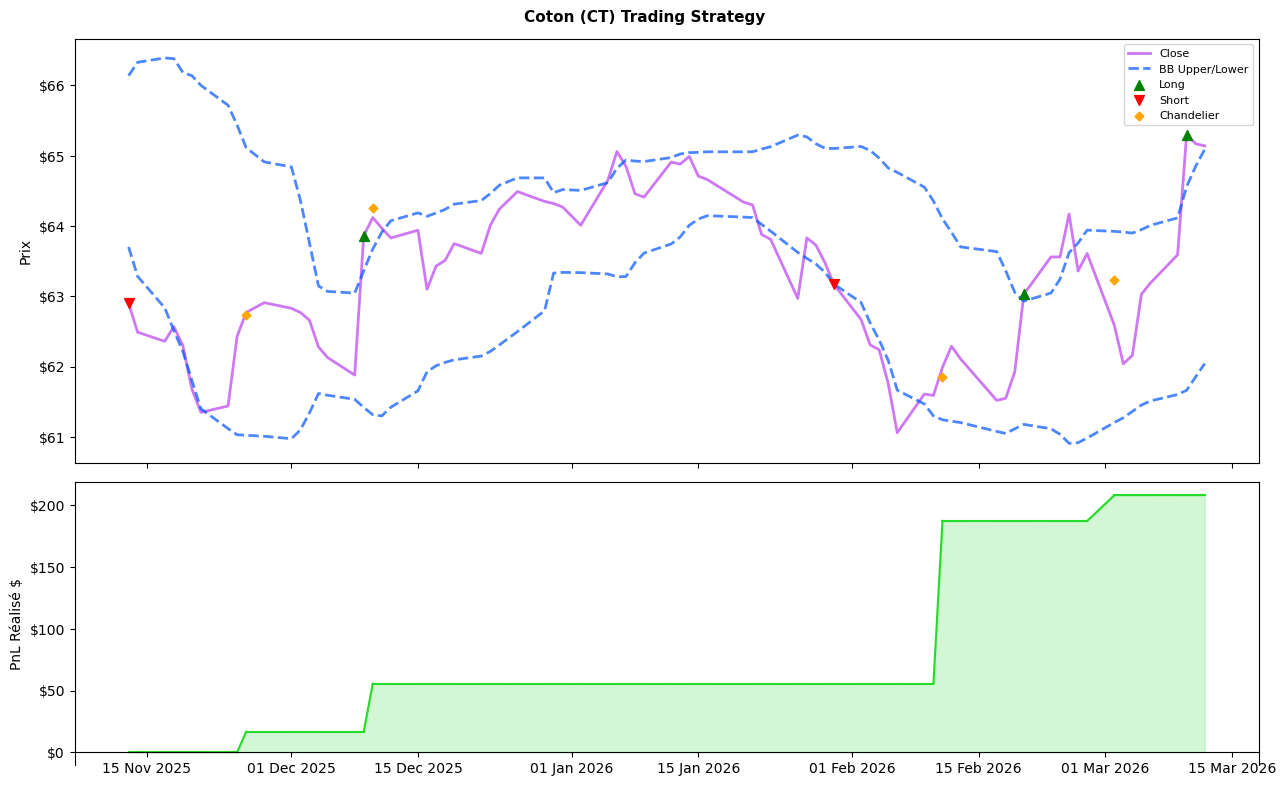


Sucre (2025-11-13 à Aujourd'hui) Trading Strategy
Trades : 3
Winrate : 33.3%
PnL Total : $-40
Meilleur : $18
Pire : $-31
Moyenne/trade : $-13
LONG : n=1 $18 wr=100.0%
SHORT : n=2 $-58 wr=0.0%


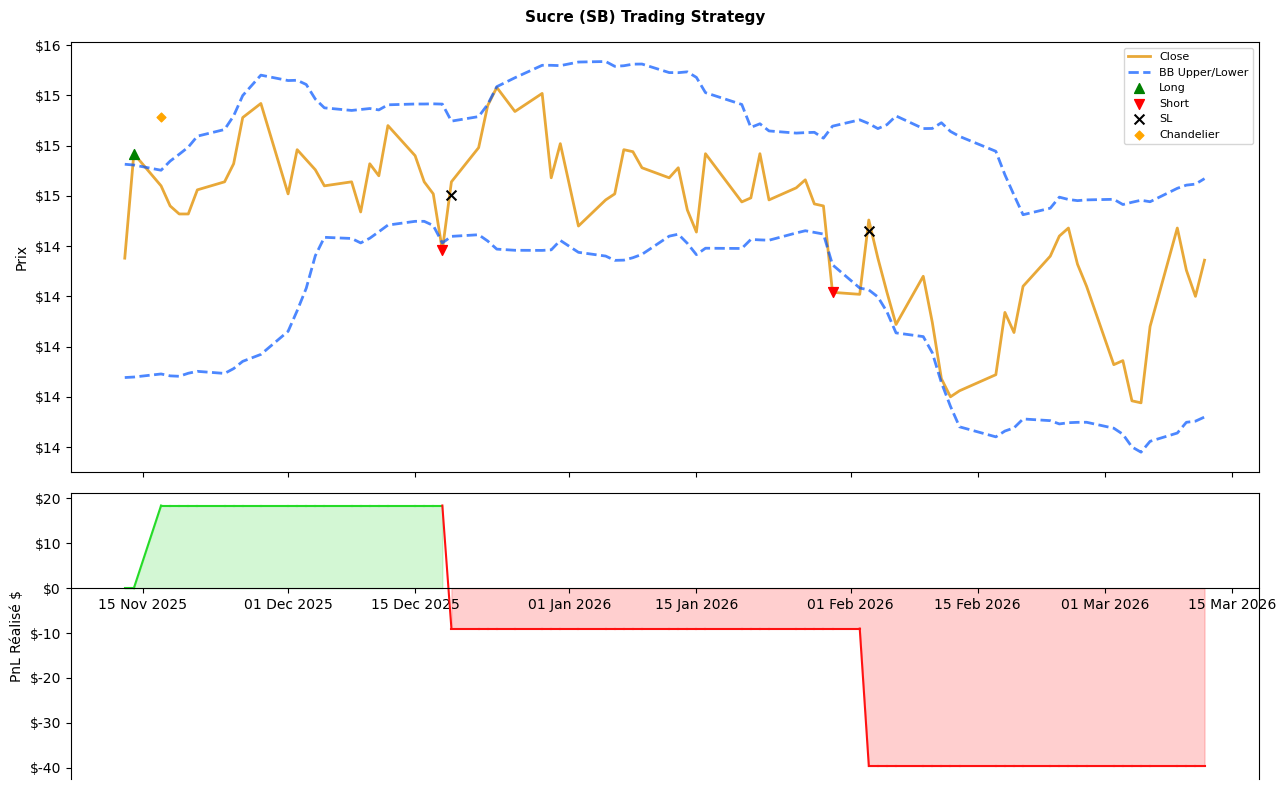


═════════════════════════════════════════════════════════
Ticker       Return $   Return %   Sharpe
─────────────────────────────────────────────────────
Café             +908      +0.9%     1.04
Cacao        +146,182    +146.2%     2.08
Coton            +208      +0.2%     2.64
Sucre             -40      -0.0%    -1.55
─────────────────────────────────────────────────────
Total        +147,259    +147.3%     2.11
Ann. Return                 +458.1%
═════════════════════════════════════════════════════════


In [13]:
PARAMS = {
    "KC": {"contracts": 100, "bb_period": 15, "bb_std": 1.5, "atr_period": 20, "atr_expansion": 0.80, "sl_atr": 2.0, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "CC": {"contracts": 100, "bb_period": 15, "bb_std": 2.0, "atr_period": 14, "atr_expansion": 1.2, "sl_atr": 1.5, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "CT": {"contracts": 100, "bb_period": 15, "bb_std": 1.5, "atr_period": 20, "atr_expansion": 0.8, "sl_atr": 2.0, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "SB": {"contracts": 100, "bb_period": 15, "bb_std": 2.0, "atr_period": 20, "atr_expansion": 0.8, "sl_atr": 2.0, "chandelier_atr": 3.0, "tp_atr": 8.0},
}

NAMES = {"KC": "Café", "CC": "Cacao", "CT": "Coton", "SB": "Sucre"}

def indicators(prices, p):
    df = pd.DataFrame({"close": prices})

    df["bb_mid"] = df["close"].rolling(p["bb_period"]).mean()
    std = df["close"].rolling(p["bb_period"]).std()
    df["bb_upper"] = df["bb_mid"] + p["bb_std"] * std
    df["bb_lower"] = df["bb_mid"] - p["bb_std"] * std

    tr = pd.concat([(df["close"] - df["close"].shift(1)).abs(), df["close"].diff().abs()], axis=1).max(axis=1)
    df["atr"] = tr.rolling(p["atr_period"]).mean()
    df["atr_mean"] = df["atr"].rolling(50).mean()

    df["ch_long"] = df["close"].rolling(p["atr_period"]).max() - p["chandelier_atr"] * df["atr"]
    df["ch_short"] = df["close"].rolling(p["atr_period"]).min() + p["chandelier_atr"] * df["atr"]

    prev = df["close"].shift(1)
    df["bu"] = (df["close"] > df["bb_upper"]) & (prev <= df["bb_upper"].shift(1))
    df["bd"] = (df["close"] < df["bb_lower"]) & (prev >= df["bb_lower"].shift(1))

    return df.dropna()

def backtest(prices, p):
    df = indicators(prices, p)
    qty = p["contracts"]

    pos = None
    trades = []
    curve = []
    cumul = 0.0
    last_sl = None

    for date, row in df.iterrows():
        price = row["close"]
        atr = row["atr"]

        if pos is not None:
            side = pos["side"]
            d = 1 if side == "long" else -1

            if side == "long":
                pos["trail"] = max(pos["trail"], row["ch_long"])
            else:
                pos["trail"] = min(pos["trail"], row["ch_short"])

            tp_hit = (side == "long" and price >= pos["tp"]) or (side == "short" and price <= pos["tp"])
            trail_hit = (side == "long" and price <= pos["trail"]) or (side == "short" and price >= pos["trail"])
            sl_hit = (side == "long" and price <= pos["sl"]) or (side == "short" and price >= pos["sl"])

            if tp_hit or trail_hit or sl_hit:
                if tp_hit:
                    ex, tag = pos["tp"], f"TP ${pos['tp']:.0f}"
                elif trail_hit:
                    ex, tag = pos["trail"], "CHANDELIER"
                else:
                    ex, tag = pos["sl"], "STOP LOSS"

                pnl = d * (ex - pos["entry"]) * qty
                cumul += pnl
                trades.append({"date": date, "side": side, "action": tag, "price": ex, "qty": qty, "pnl": pnl, "cumul_pnl": cumul})
                pos = None
                last_sl = date
                curve.append({"date": date, "cumul_pnl": cumul})
                continue

        else:
            if last_sl is None or date > last_sl:
                exp = atr > p["atr_expansion"] * row["atr_mean"]

                if row["bu"] and exp:
                    pos = {"side": "long", "entry": price, "sl": price - p["sl_atr"] * atr, "tp": price + p["tp_atr"] * atr, "trail": row["ch_long"]}
                    trades.append({"date": date, "side": "long", "action": "ENTREE LONG", "price": price, "qty": qty, "pnl": 0, "cumul_pnl": cumul})

                elif row["bd"] and exp:
                    pos = {"side": "short", "entry": price, "sl": price + p["sl_atr"] * atr, "tp": price - p["tp_atr"] * atr, "trail": row["ch_short"]}
                    trades.append({"date": date, "side": "short", "action": "ENTREE SHORT", "price": price, "qty": qty, "pnl": 0, "cumul_pnl": cumul})

        curve.append({"date": date, "cumul_pnl": cumul})

    return {
        "df": df,
        "trades": pd.DataFrame(trades),
        "curve": pd.DataFrame(curve).set_index("date"),
        "total": cumul,
    }

def summary(trades, name):
    closed = trades[trades["pnl"] != 0]
    wins = closed[closed["pnl"] > 0]
    losses = closed[closed["pnl"] < 0]

    print(f"\n{name} Trading Strategy")
    print(f"Trades : {len(closed)}")
    print(f"Winrate : {100*len(wins)/len(closed):.1f}%")
    print(f"PnL Total : ${closed['pnl'].sum():,.0f}")
    print(f"Meilleur : ${closed['pnl'].max():,.0f}")
    print(f"Pire : ${closed['pnl'].min():,.0f}")
    print(f"Moyenne/trade : ${closed['pnl'].mean():,.0f}")

    for side in ["long", "short"]:
        sub = closed[closed["side"] == side]
        if not sub.empty:
            wr = 100 * len(sub[sub["pnl"] > 0]) / len(sub)
            print(f"{side.upper()} : n={len(sub)} ${sub['pnl'].sum():,.0f} wr={wr:.1f}%")

def plot_results(res, ticker, name):
    df = res["df"]
    tr = res["trades"]
    curve = res["curve"]

    el = tr[tr["action"] == "ENTREE LONG"]
    es = tr[tr["action"] == "ENTREE SHORT"]
    sl = tr[tr["action"] == "STOP LOSS"]
    ch = tr[tr["action"] == "CHANDELIER"]
    tp = tr[tr["action"].str.startswith("TP")]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
    fig.suptitle(f"{name} ({ticker}) Trading Strategy", fontsize=11, fontweight="bold")

    ax1.plot(df.index, df["close"], lw=2, color=COLORS[ticker], label="Close")
    ax1.plot(df.index, df["bb_upper"], lw=2, color="#0055FF", linestyle="--", label="BB Upper/Lower", alpha=0.7)
    ax1.plot(df.index, df["bb_lower"], lw=2, color="#0055FF", linestyle="--", alpha=0.7)

    for data, marker, color, label, sz in [
        (el, "^", "green", "Long", 50),
        (es, "v", "red", "Short", 50),
        (sl, "x", "black", "SL", 50),
        (ch, "D", "orange", "Chandelier", 20),
        (tp, "*", "purple", "TP", 50),
    ]:
        if not data.empty:
            ax1.scatter(data["date"], data["price"], marker=marker, color=color, s=sz, zorder=5, label=label)

    ax1.set_ylabel("Prix")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax1.legend(loc="upper right", fontsize=8)

    for i in range(1, len(curve)):
      col = "#25DB28" if curve["cumul_pnl"].iloc[i] >= 0 else "#FF1212"
      ax2.plot(curve.index[i-1:i+1], curve["cumul_pnl"].iloc[i-1:i+1], lw=1.5, color=col)

    ax2.spines["bottom"].set_position(("data", 0))
    ax2.fill_between(curve.index, curve["cumul_pnl"], 0, where=curve["cumul_pnl"] >= 0, alpha=0.2, color="#25DB28")
    ax2.fill_between(curve.index, curve["cumul_pnl"], 0, where=curve["cumul_pnl"] < 0, alpha=0.2, color="#FF1212")
    ax2.set_ylabel("PnL Réalisé $")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b %Y"))

    plt.tight_layout()
    plt.show()
    plt.close()

results = {}
for ticker, name in NAMES.items():
    prices_full = pd.concat([df_hist[ticker], df_recent[ticker]]).dropna().sort_index()
    prices_full = prices_full[~prices_full.index.duplicated(keep="last")]

    res = backtest(prices_full, PARAMS[ticker])
    trades_recent = res["trades"][res["trades"]["date"] >= "2025-11-13"]
    curve_recent = res["curve"][res["curve"].index >= "2025-11-13"]

    res_recent = {
        "df": res["df"][res["df"].index >= "2025-11-13"],
        "trades": trades_recent,
        "curve": curve_recent - curve_recent.iloc[0],
        "total": trades_recent[trades_recent["pnl"] != 0]["pnl"].sum() if not trades_recent.empty else 0,
    }

    summary(res_recent["trades"], f"{name} (2025-11-13 à Aujourd'hui)")
    plot_results(res_recent, ticker, name)
    results[ticker] = (res_recent, name)

global_summary(results)

## Rapport PDF Signaux à envoyer à l'Equipe

In [14]:
PARAMS = {
    "KC": {"contracts": 100, "bb_period": 15, "bb_std": 1.5, "atr_period": 20, "atr_expansion": 0.80, "sl_atr": 2.0, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "CC": {"contracts": 100, "bb_period": 15, "bb_std": 2.0, "atr_period": 14, "atr_expansion": 1.2,  "sl_atr": 1.5, "chandelier_atr": 2.5, "tp_atr": 8.0, "ema_filter": 100},
    "CT": {"contracts": 100, "bb_period": 15, "bb_std": 1.5, "atr_period": 20, "atr_expansion": 0.80, "sl_atr": 2.0, "chandelier_atr": 2.5, "tp_atr": 8.0},
    "SB": {"contracts": 100, "bb_period": 15, "bb_std": 2.0, "atr_period": 20, "atr_expansion": 0.80, "sl_atr": 2.0, "chandelier_atr": 3.0, "tp_atr": 8.0},
}
USE_EMA = {"KC": False, "CC": True, "CT": False, "SB": False}

def indicators(prices, p, use_ema=False):
    df = pd.DataFrame({"close": prices})

    df["bb_mid"] = df["close"].rolling(p["bb_period"]).mean()
    std = df["close"].rolling(p["bb_period"]).std()
    df["bb_upper"] = df["bb_mid"] + p["bb_std"] * std
    df["bb_lower"] = df["bb_mid"] - p["bb_std"] * std
    df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["bb_mid"]

    tr = pd.concat([(df["close"] - df["close"].shift(1)).abs(), df["close"].diff().abs()], axis=1).max(axis=1)
    df["atr"] = tr.rolling(p["atr_period"]).mean()
    df["atr_mean"] = df["atr"].rolling(50).mean()

    df["ch_long"] = df["close"].rolling(p["atr_period"]).max() - p["chandelier_atr"] * df["atr"]
    df["ch_short"] = df["close"].rolling(p["atr_period"]).min() + p["chandelier_atr"] * df["atr"]

    df["ema_50"] = df["close"].ewm(span=50).mean()
    df["ema_200"] = df["close"].ewm(span=200).mean()
    if use_ema and "ema_filter" in p:
        df["ema_filter"] = df["close"].ewm(span=int(p["ema_filter"]), adjust=False).mean()

    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df["rsi"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    df["returns"] = df["close"].pct_change()
    df["vol_21"] = df["returns"].rolling(21).std() * np.sqrt(252)

    prev = df["close"].shift(1)
    df["bu"] = (df["close"] > df["bb_upper"]) & (prev <= df["bb_upper"].shift(1))
    df["bd"] = (df["close"] < df["bb_lower"]) & (prev >= df["bb_lower"].shift(1))

    return df.dropna()

def generate_signal(ticker, prices):
    p = PARAMS[ticker]
    use_ema = USE_EMA[ticker]
    df = indicators(prices, p, use_ema)
    row = df.iloc[-1]
    price = float(row["close"])
    atr = float(row["atr"])
    exp = atr > p["atr_expansion"] * float(row["atr_mean"])

    long_ok = bool(row["bu"]) and exp and (not use_ema or price > float(row.get("ema_filter", price - 1)))
    short_ok = bool(row["bd"]) and exp and (not use_ema or price < float(row.get("ema_filter", price + 1)))

    if long_ok:
        signal, side = "BUY", "BUY"
        sl = round(price - p["sl_atr"] * atr, 2)
        tp = round(price + p["tp_atr"] * atr, 2)
    elif short_ok:
        signal, side = "SELL", "SELL"
        sl = round(price + p["sl_atr"] * atr, 2)
        tp = round(price - p["tp_atr"] * atr, 2)
    else:
        signal, side, sl, tp = "NEUTRAL", None, None, None

    recent = df.iloc[-20:]
    sig_list = []
    for d, r in recent.iterrows():
        exp_r = float(r["atr"]) > p["atr_expansion"] * float(r["atr_mean"])
        lo = bool(r["bu"]) and exp_r
        so = bool(r["bd"]) and exp_r
        if lo:
            sig_list.append((d, "BUY", round(float(r["close"]), 2)))
        elif so:
            sig_list.append((d, "SELL", round(float(r["close"]), 2)))

    rets = df["returns"].dropna()

    return {
        "ticker": ticker,
        "name": NAMES[ticker],
        "date": df.index[-1].date(),
        "price": round(price, 2),
        "signal": signal,
        "side": side,
        "sl": sl,
        "tp": tp,
        "atr": round(atr, 2),
        "atr_expanding": exp,
        "bb_upper": round(float(row["bb_upper"]), 2),
        "bb_lower": round(float(row["bb_lower"]), 2),
        "bb_mid": round(float(row["bb_mid"]),   2),
        "bb_width": round(float(row["bb_width"]) * 100, 2),
        "ch_long": round(float(row["ch_long"]),  2),
        "ch_short": round(float(row["ch_short"]), 2),
        "ema_50": round(float(row["ema_50"]),   2),
        "ema_200": round(float(row["ema_200"]),  2),
        "ema_trend": "HAUSSIER" if row["ema_50"] > row["ema_200"] else "BAISSIER",
        "rsi": round(float(row["rsi"]), 1),
        "vol_current": round(float(row["vol_21"]) * 100, 1),
        "vol_mean": round(float(df["vol_21"].mean()) * 100, 1),
        "skew": round(float(rets.skew()), 2),
        "kurt": round(float(rets.kurt()), 2),
        "recent_signals": sig_list,
        "df": df,
    }


def interpret(s):
    lines = []

    if s["ema_trend"] == "HAUSSIER":
        lines.append("Tendance longue haussiere (EMA50 > EMA200).")
    else:
        lines.append("Tendance longue baissiere (EMA50 < EMA200).")

    rsi = s["rsi"]
    if rsi > 70:
        lines.append(f"RSI a {rsi} : zone de surchauffe, prudence sur les longs.")
    elif rsi < 30:
        lines.append(f"RSI a {rsi} : zone de survente, rebond possible.")
    else:
        lines.append(f"RSI a {rsi} : zone neutre.")

    if s["vol_current"] > s["vol_mean"] * 1.3:
        lines.append(f"Volatilite elevee ({s['vol_current']}% vs moy {s['vol_mean']}%) : stops plus larges conseilles.")
    elif s["vol_current"] < s["vol_mean"] * 0.7:
        lines.append(f"Volatilite basse ({s['vol_current']}% vs moy {s['vol_mean']}%) : breakouts moins fiables.")

    if abs(s["skew"]) > 0.5:
        dir_skew = "positive (queues de gains)" if s["skew"] > 0 else "negative (queues de pertes)"
        lines.append(f"Distribution asymetrique {dir_skew} (skew {s['skew']:+.2f}).")
    if s["kurt"] > 3:
        lines.append(f"Kurtosis eleve ({s['kurt']:.1f}) : mouvements extremes plus frequents.")

    if s["signal"] == "BUY":
        lines.append(f"Signal BUY actif. Stop Loss ${s['sl']:,.2f} | Take Profit ${s['tp']:,.2f}.")
    elif s["signal"] == "SELL":
        lines.append(f"Signal SELL actif. Stop Loss ${s['sl']:,.2f} | Take Profit ${s['tp']:,.2f}.")
    else:
        lines.append("Pas de signal breakout aujourd'hui.")

    return lines


def interpret_history(s):
    df_full = s["df"]
    cutoff = df_full.index[-1] - pd.DateOffset(years=10)
    df = df_full[df_full.index >= cutoff]

    lines = []

    pmin = df["close"].min()
    pmax = df["close"].max()
    lines.append(f"Sur 10 ans : prix min ${pmin:,.2f}, max ${pmax:,.2f}.")

    first_ema50 = df["ema_50"].iloc[0]
    last_ema50 = df["ema_50"].iloc[-1]
    first_ema200 = df["ema_200"].iloc[0]
    last_ema200 = df["ema_200"].iloc[-1]
    if last_ema50 > first_ema50 and last_ema200 > first_ema200:
        trend_txt = "Tendance generale haussiere sur la periode (EMA50 et EMA200 en progression)."
    elif last_ema50 < first_ema50 and last_ema200 < first_ema200:
        trend_txt = "Tendance generale baissiere sur la periode (EMA50 et EMA200 en recul)."
    else:
        trend_txt = "Tendance mixte sur la periode (EMA50 et EMA200 divergentes)."
    cross = "au-dessus" if last_ema50 > last_ema200 else "en-dessous"
    lines.append(f"{trend_txt} Actuellement EMA50 (${last_ema50:,.2f}) est {cross} de l'EMA200 (${last_ema200:,.2f}).")

    rsi_mean = round(df["rsi"].mean(), 1)
    rsi_now = s["rsi"]
    if rsi_mean > 60:
        struct = "marche structurellement acheteur"
    elif rsi_mean < 40:
        struct = "marche structurellement vendeur"
    else:
        struct = "equilibre acheteurs/vendeurs"
    if rsi_now > 70:
        rsi_now_txt = f"RSI actuel a {rsi_now} : zone de surchauffe."
    elif rsi_now < 30:
        rsi_now_txt = f"RSI actuel a {rsi_now} : zone de survente."
    else:
        rsi_now_txt = f"RSI actuel a {rsi_now} : zone neutre."
    lines.append(f"RSI moyen sur 10 ans de {rsi_mean} ({struct}). {rsi_now_txt}")

    vol_mean_10y = round(df["vol_21"].mean() * 100, 1)
    vol_now = round(df["vol_21"].iloc[-1] * 100, 1)
    if vol_now > vol_mean_10y * 1.3:
        lines.append(f"Volatilite actuelle ({vol_now}%) nettement superieure a la moyenne 10 ans ({vol_mean_10y}%) : regime de forte incertitude.")
    elif vol_now < vol_mean_10y * 0.7:
        lines.append(f"Volatilite actuelle ({vol_now}%) nettement inferieure a la moyenne 10 ans ({vol_mean_10y}%) : regime de calme inhabituel.")
    else:
        lines.append(f"Volatilite actuelle ({vol_now}%) proche de la moyenne historique ({vol_mean_10y}%).")

    return lines

def make_chart(ticker, s):
    df = s["df"].iloc[-180:]
    p = PARAMS[ticker]
    color = COLORS[ticker]
    use_ema = USE_EMA[ticker]

    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})
    fig.patch.set_facecolor("#0f0f0f")
    for ax in axes:
        ax.set_facecolor("#1a1a1a")
        ax.tick_params(colors="white", labelsize=7)
        for spine in ax.spines.values():
            spine.set_color("#444")

    ax1 = axes[0]
    ax1.plot(df.index, df["close"], lw=1.2, color=color, label="Close")
    ax1.plot(df.index, df["bb_upper"], lw=0.8, color="steelblue", linestyle="--", alpha=0.7, label="BB")
    ax1.plot(df.index, df["bb_mid"], lw=0.6, color="grey", linestyle="--", alpha=0.5)
    ax1.plot(df.index, df["bb_lower"], lw=0.8, color="steelblue", linestyle="--", alpha=0.7)
    ax1.fill_between(df.index, df["bb_lower"], df["bb_upper"], alpha=0.04, color="steelblue")
    ax1.plot(df.index, df["ema_50"], lw=1, color="#FFD700", alpha=0.8, label="EMA 50")
    ax1.plot(df.index, df["ema_200"], lw=1, color="#FF4444", alpha=0.8, label="EMA 200")
    if use_ema and "ema_filter" in df.columns:
        ax1.plot(df.index, df["ema_filter"], lw=1, color="orange", linestyle=":", alpha=0.8, label=f"EMA {p['ema_filter']}")

    for d, sig, prc in s["recent_signals"]:
        if d in df.index:
            mk = "^" if sig == "BUY" else "v"
            cl = "lime" if sig == "BUY" else "tomato"
            ax1.scatter([d], [prc], marker=mk, color=cl, s=100, zorder=10)

    if s["side"] == "BUY":
        ax1.axhline(s["sl"], color="red", lw=0.8, linestyle="--", alpha=0.8, label=f"SL {s['sl']:.2f}")
        ax1.axhline(s["tp"], color="lime", lw=0.8, linestyle="--", alpha=0.8, label=f"TP {s['tp']:.2f}")
    elif s["side"] == "SELL":
        ax1.axhline(s["sl"], color="red", lw=0.8, linestyle="--", alpha=0.8, label=f"SL {s['sl']:.2f}")
        ax1.axhline(s["tp"], color="tomato", lw=0.8, linestyle="--", alpha=0.8, label=f"TP {s['tp']:.2f}")

    ax1.set_ylabel("Prix ($)", color="white", fontsize=8)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.2f}"))
    ax1.legend(loc="upper left", fontsize=6, facecolor="#222", labelcolor="white", ncol=4, framealpha=0.7)
    ax1.grid(True, alpha=0.15)

    ax2 = axes[1]
    ax2.plot(df.index, df["rsi"], lw=1, color="#5ABDFF")
    ax2.axhline(70, lw=0.7, color="red", linestyle="--", alpha=0.7)
    ax2.axhline(30, lw=0.7, color="green", linestyle="--", alpha=0.7)
    ax2.axhline(50, lw=0.5, color="grey", linestyle="--", alpha=0.4)
    ax2.set_ylabel("RSI 14", color="white", fontsize=8)
    ax2.set_ylim(0, 100)
    ax2.grid(True, alpha=0.15)

    ax3 = axes[2]
    ax3.plot(df.index, df["vol_21"] * 100, lw=1, color="#E33FBD")
    ax3.axhline(df["vol_21"].mean() * 100, lw=0.7, color="white", linestyle="--", alpha=0.5, label=f"Moy {df['vol_21'].mean()*100:.1f}%")
    ax3.set_ylabel("Vol Annuelle %", color="white", fontsize=8)
    ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=20, ha="right", color="white", fontsize=7)
    ax3.legend(fontsize=6, facecolor="#222", labelcolor="white", framealpha=0.7)
    ax3.grid(True, alpha=0.15)

    fig.suptitle(
        f"{NAMES[ticker]} ({ticker})  —  {s['signal']}  |  Close: ${s['price']:,.2f}",
        color="white", fontsize=11, fontweight="bold"
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    return buf

def make_history_chart(ticker, s):
    df = s["df"]
    cutoff = df.index[-1] - pd.DateOffset(years=10)
    df = df[df.index >= cutoff]
    color = COLORS[ticker]

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})
    fig.patch.set_facecolor("#0f0f0f")
    for ax in axes:
        ax.set_facecolor("#1a1a1a")
        ax.tick_params(colors="white", labelsize=7)
        for spine in ax.spines.values():
            spine.set_color("#444")

    ax1 = axes[0]
    ax1.plot(df.index, df["close"], lw=1.2, color=color, label="Prix")
    ax1.plot(df.index, df["ema_50"],  lw=1, color="#FFD700", alpha=0.8, label="EMA 50")
    ax1.plot(df.index, df["ema_200"], lw=1, color="#FF4444", alpha=0.8, label="EMA 200")
    ax1.set_ylabel("Prix $", color="white", fontsize=8)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.2f}"))
    ax1.legend(loc="upper left", fontsize=6, facecolor="#222", labelcolor="white", framealpha=0.7)
    ax1.grid(True, alpha=0.15)

    ax2 = axes[1]
    ax2.plot(df.index, df["rsi"], lw=1, color="#5ABDFF")
    ax2.axhline(70, lw=0.7, color="red", linestyle="--", alpha=0.7)
    ax2.axhline(30, lw=0.7, color="green", linestyle="--", alpha=0.7)
    ax2.axhline(50, lw=0.5, color="grey", linestyle="--", alpha=0.4)
    ax2.set_ylabel("RSI 14", color="white", fontsize=8)
    ax2.set_ylim(0, 100)
    ax2.grid(True, alpha=0.15)

    ax3 = axes[2]
    ax3.plot(df.index, df["vol_21"] * 100, lw=1, color="#E33FBD")
    ax3.axhline(df["vol_21"].mean() * 100, lw=0.7, color="white", linestyle="--", alpha=0.5, label=f"Moy {df['vol_21'].mean()*100:.1f}%")
    ax3.set_ylabel("Vol Annuelle %", color="white", fontsize=8)
    ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
    ax3.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    plt.setp(ax3.xaxis.get_majorticklabels(), color="white", fontsize=7)
    ax3.legend(fontsize=6, facecolor="#222", labelcolor="white", framealpha=0.7)
    ax3.grid(True, alpha=0.15)

    fig.suptitle(
        f"{NAMES[ticker]} ({ticker}) — 10-Year Price History",
        color="white", fontsize=10, fontweight="bold"
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    return buf

def generate_pdf(signals, charts, history_charts, out_path):
    doc = SimpleDocTemplate(
        out_path, pagesize=A4,
        leftMargin=1.5*cm, rightMargin=1.5*cm,
        topMargin=1.2*cm, bottomMargin=1.2*cm,
    )

    styles = getSampleStyleSheet()
    DARK = colors.HexColor("#1a1a2e")
    LIGHT = colors.HexColor("#f8f9fa")
    BORDER = colors.HexColor("#dee2e6")

    title_style = ParagraphStyle("title", parent=styles["Title"], fontSize=20, textColor=DARK, spaceAfter=2, alignment=TA_CENTER)
    sub_style = ParagraphStyle("sub", parent=styles["Normal"], fontSize=9, textColor=colors.grey, spaceAfter=8, alignment=TA_CENTER)
    h2_style = ParagraphStyle("h2", parent=styles["Heading2"], fontSize=11, textColor=DARK, spaceBefore=6, spaceAfter=4)
    body_style = ParagraphStyle("body",  parent=styles["Normal"], fontSize=8, textColor=colors.HexColor("#333333"), leading=13, spaceAfter=2)

    def sig_bg(sig):
        if sig == "BUY": return colors.HexColor("#d4edda")
        if sig == "SELL": return colors.HexColor("#f8d7da")
        return LIGHT

    def sig_tc(sig):
        if sig == "BUY": return colors.HexColor("#155724")
        if sig == "SELL": return colors.HexColor("#721c24")
        return colors.HexColor("#444444")

    story = []

    today = datetime.now().strftime("%d %B %Y  %H:%M")
    story.append(Spacer(1, 0.5*cm))
    story.append(Paragraph("Signal Report", title_style))
    story.append(Paragraph(f"Generated on {today}", sub_style))
    story.append(HRFlowable(width="100%", thickness=2, color=DARK, spaceAfter=14))

    header = ["Commodity", "Price", "Signal", "Stop Loss", "Take Profit", "Avg True Range", "Trend", "RSI", "Vol %"]
    rows = [header]
    row_bg = []
    for s in signals:
        rows.append([
            f"{s['name']} ({s['ticker']})",
            f"${s['price']:,.2f}",
            s["signal"],
            f"${s['sl']:,.2f}" if s["sl"] else "—",
            f"${s['tp']:,.2f}" if s["tp"] else "—",
            f"${s['atr']:,.2f}",
            s["ema_trend"],
            str(s["rsi"]),
            f"{s['vol_current']}%",
        ])
        row_bg.append(sig_bg(s["signal"]))

    col_w = [3*cm, 2.3*cm, 2*cm, 2.3*cm, 2.3*cm, 2.3*cm, 2.2*cm, 1.3*cm, 1.5*cm]
    t = Table(rows, colWidths=col_w)
    ts = TableStyle([
        ("BACKGROUND", (0,0), (-1,0), DARK),
        ("TEXTCOLOR", (0,0), (-1,0), colors.white),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE", (0,0), (-1,-1), 7.5),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
        ("ROWHEIGHT", (0,0), (-1,-1), 20),
        ("GRID", (0,0), (-1,-1), 0.5, BORDER),
    ])
    for i, bg in enumerate(row_bg):
        ts.add("BACKGROUND", (0, i+1), (-1, i+1), bg)
        ts.add("TEXTCOLOR", (2, i+1), (2,  i+1), sig_tc(signals[i]["signal"]))
        ts.add("FONTNAME", (2, i+1), (2,  i+1), "Helvetica-Bold")
    t.setStyle(ts)
    story.append(t)
    story.append(Spacer(1, 0.4*cm))

    n_buy = sum(1 for s in signals if s["signal"] == "BUY")
    n_sell = sum(1 for s in signals if s["signal"] == "SELL")
    n_neu = sum(1 for s in signals if s["signal"] == "NEUTRAL")
    story.append(Paragraph(
        f"<b>{n_buy} Buy</b>  |  <b>{n_sell} Sell</b>  |  <b>{n_neu} Neutral</b>",
        ParagraphStyle("summ", parent=styles["Normal"], fontSize=10, textColor=DARK, alignment=TA_CENTER, spaceAfter=4)
    ))

    for s in signals:
        story.append(PageBreak())
        p = PARAMS[s["ticker"]]

        commodity_title = ParagraphStyle("ctitle", parent=styles["Title"], fontSize=16, textColor=DARK, spaceAfter=2, alignment=TA_CENTER)
        story.append(Paragraph(f"{s['name']} ({s['ticker']})", commodity_title))
        story.append(Paragraph(f"Closing {s['date'].strftime('%d/%m/%Y')}  —  Price: ${s['price']:,.2f}", sub_style))
        story.append(HRFlowable(width="100%", thickness=1.5, color=DARK, spaceAfter=6))

        badge_style = ParagraphStyle("badge", parent=styles["Normal"], fontSize=13, alignment=TA_CENTER, textColor=sig_tc(s["signal"]), spaceAfter=6, backColor=sig_bg(s["signal"]), borderPadding=5)
        story.append(Paragraph(f"<b>Signal : {s['signal']}</b>", badge_style))
        story.append(Spacer(1, 0.15*cm))

        if s["ticker"] in charts:
            story.append(Image(charts[s["ticker"]], width=17*cm, height=11*cm))
        story.append(Spacer(1, 0.3*cm))

        left = [["Key Levels", ""]]
        right = [["Statistics", ""]]

        if s["sl"]: left.append(["Stop Loss", f"${s['sl']:,.2f}"])
        if s["tp"]: left.append(["Take Profit", f"${s['tp']:,.2f}"])
        left.append(["Bollinger Bands Upper", f"${s['bb_upper']:,.2f}"])
        left.append(["Bollinger Bands Mid", f"${s['bb_mid']:,.2f}"])
        left.append(["Bollinger Bands Lower", f"${s['bb_lower']:,.2f}"])
        left.append(["Bollinger Bands Width", f"{s['bb_width']:.2f}%"])
        left.append(["Average True Range", f"${s['atr']:,.2f}"])
        left.append(["Chandelier Long", f"${s['ch_long']:,.2f}"])
        left.append(["Chandelier Short", f"${s['ch_short']:,.2f}"])

        right.append(["EMA 50", f"${s['ema_50']:,.2f}"])
        right.append(["EMA 200", f"${s['ema_200']:,.2f}"])
        right.append(["Trend", s["ema_trend"]])
        right.append(["RSI 14", str(s["rsi"])])
        right.append(["Volatilite Actuelle", f"{s['vol_current']}%"])
        right.append(["Volatilite Moyenne", f"{s['vol_mean']}%"])
        right.append(["Skew", f"{s['skew']:+.2f}"])
        right.append(["Kurtosis", f"{s['kurt']:+.2f}"])
        right.append(["Contracts", str(p["contracts"])])

        def detail_table(data):
            t = Table(data, colWidths=[3.8*cm, 3.8*cm])
            t.setStyle(TableStyle([
                ("BACKGROUND", (0,0), (-1,0), DARK),
                ("TEXTCOLOR", (0,0), (-1,0), colors.white),
                ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
                ("SPAN", (0,0), (-1,0)),
                ("ALIGN", (0,0), (-1,0), "CENTER"),
                ("FONTNAME", (0,1), (-1,-1), "Helvetica"),
                ("FONTSIZE", (0,0), (-1,-1), 7.5),
                ("ALIGN", (1,1), (1,-1), "RIGHT"),
                ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
                ("ROWHEIGHT", (0,0), (-1,-1), 14),
                ("GRID", (0,0), (-1,-1), 0.5, BORDER),
                ("ROWBACKGROUNDS", (0,1), (-1,-1), [LIGHT, colors.white]),
            ]))
            return t

        two_col = Table([[detail_table(left), detail_table(right)]], colWidths=[8.5*cm, 8.5*cm])
        two_col.setStyle(TableStyle([
            ("VALIGN", (0,0), (-1,-1), "TOP"),
            ("LEFTPADDING", (0,0), (-1,-1), 4),
            ("RIGHTPADDING", (0,0), (-1,-1), 4),
        ]))
        story.append(two_col)
        story.append(Spacer(1, 0.35*cm))

        story.append(Paragraph("Signals — Last 20 Days", h2_style))
        if s["recent_signals"]:
            sig_rows = [["Date", "Signal", "Price"]]
            for d, sig, prc in s["recent_signals"]:
                sig_rows.append([d.strftime("%d/%m/%Y"), sig, f"${prc:,.2f}"])
            sig_t = Table(sig_rows, colWidths=[3*cm, 3*cm, 3*cm])
            sig_ts = TableStyle([
                ("BACKGROUND", (0,0), (-1,0), DARK),
                ("TEXTCOLOR", (0,0), (-1,0), colors.white),
                ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
                ("FONTSIZE", (0,0), (-1,-1), 8),
                ("ALIGN", (0,0), (-1,-1), "CENTER"),
                ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
                ("ROWHEIGHT", (0,0), (-1,-1), 16),
                ("GRID", (0,0), (-1,-1), 0.5, BORDER),
            ])
            for i, row in enumerate(sig_rows[1:], 1):
                bg = sig_bg(row[1])
                tc = sig_tc(row[1])
                sig_ts.add("BACKGROUND", (0,i), (-1,i), bg)
                sig_ts.add("TEXTCOLOR", (1,i), (1,i), tc)
                sig_ts.add("FONTNAME", (1,i), (1,i), "Helvetica-Bold")
            sig_t.setStyle(sig_ts)
            story.append(sig_t)
        else:
            story.append(Paragraph("No signals in the last 20 days.", body_style))

        story.append(Spacer(1, 0.35*cm))
        story.append(Paragraph("Interpretation", h2_style))
        for line in interpret(s):
            story.append(Paragraph(f"• {line}", body_style))

        story.append(CondPageBreak(8.5*cm))
        story.append(Spacer(1, 0.3*cm))
        story.append(Paragraph("10-Year Price History", h2_style))
        if s["ticker"] in history_charts:
            story.append(Image(history_charts[s["ticker"]], width=17*cm, height=10*cm))
        story.append(Spacer(1, 0.35*cm))
        story.append(Paragraph("10-Year Interpretation", h2_style))
        for line in interpret_history(s):
            story.append(Paragraph(f"• {line}", body_style))

    doc.build(story)
    print(f"PDF genere -> {out_path}")

df_hist = pd.read_csv("continuous_series/ALL_continuous_OI_close.csv", index_col=0, parse_dates=True)
df_recent = pd.read_csv("continuous_series/ALL_continuous_OI_close_recent.csv", index_col=0, parse_dates=True)

out_dir = Path("signals")
out_dir.mkdir(exist_ok=True)

signals = []
charts = {}
history_charts = {}

for ticker in PARAMS:
    print(f"{NAMES[ticker]} ({ticker})...")
    prices = pd.concat([df_hist[ticker], df_recent[ticker]]).dropna().sort_index()
    prices = prices[~prices.index.duplicated(keep="last")]
    s = generate_signal(ticker, prices)
    signals.append(s)
    charts[ticker] = make_chart(ticker, s)
    history_charts[ticker] = make_history_chart(ticker, s)
    print(f"Signal : {s['signal']} | Prix : ${s['price']:,.2f}")

pdf_path = out_dir / f"signals_{date.today().strftime('%Y%m%d')}.pdf"
generate_pdf(signals, charts, history_charts, str(pdf_path))

print(f"\nRapport disponible : {pdf_path}")

Café (KC)...
Signal : NEUTRAL | Prix : $285.15
Cacao (CC)...
Signal : NEUTRAL | Prix : $3,223.00
Coton (CT)...
Signal : NEUTRAL | Prix : $65.82
Sucre (SB)...
Signal : NEUTRAL | Prix : $14.41
PDF genere -> signals/signals_20260313.pdf

Rapport disponible : signals/signals_20260313.pdf
